# 전처리 및 변수 설정

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# ==========================================
# [실험 설정 구간] 모든 하이퍼파라미터 통합 
# ==========================================
DATA_PATH = '../CMAPSSData/'
CONFIG = {
    'DATA_ID': 'FD001',
    'RUL_CAP': 125,
    'GAUSS_SIGMA': 2,
    'RANDOM_STATE': 42,
    'TEST_SIZE': 0.2,
    'SCALER_TYPE': 'minmax',  # minmax , Standard
    
    # 사용할 센서 직접 지정 (상수 센서 자동 감지 대신 사용 )
    'BASE_SENSORS': ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                     's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'],
    'SETTING_FEATURES': ['setting_1', 'setting_2', 'setting_3'],

    # 파생변수 설정
    'USE_MA': True,   'WIN_MA': 5,
    'USE_STD': True,  'WIN_STD': 10,  
    'USE_DIFF': True, 'PER_DIFF': 1,
    'USE_EMA': True,  'SPAN_EMA': 10,
    'USE_LAG': True,  'LAG_STEP': 10,
}

# ---------------------------------------------------------
# [1] 데이터 로드 및 초기 전처리 (Capping & 상수 제거)
# ---------------------------------------------------------
def load_and_basic_prep(config):
    # 전체 컬럼 정의
    cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    
    # 데이터 로드
    train = pd.read_csv(f"{DATA_PATH}train_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
    test = pd.read_csv(f"{DATA_PATH}test_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
    y_test_final = pd.read_csv(f"{DATA_PATH}RUL_{config['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values

    # RUL 생성 및 Capping
    train['max_cycle'] = train.groupby('unit_nr')['time_cycles'].transform('max')
    train['RUL'] = (train['max_cycle'] - train['time_cycles']).clip(upper=config['RUL_CAP'])
    train.drop(columns=['max_cycle'], inplace=True)

    # 명시적으로 선택한 컬럼만 유지 (unit_nr, time_cycles, RUL + 선택 센서 + 세팅값 )
    keep_cols = ['unit_nr', 'time_cycles'] + config['SETTING_FEATURES'] + config['BASE_SENSORS']
    
    # Train은 RUL 포함, Test는 RUL 제외하고 선택
    train = train[keep_cols + ['RUL']]
    test = test[keep_cols]
    
    print(f"✅ 센서 선택 완료: {config['BASE_SENSORS']}")
    print(f"✅ 유지된 컬럼 총 {len(train.columns)}개 (RUL 포함)")
    
    return train, test, y_test_final

# 실행 
df_train, df_test, y_test = load_and_basic_prep(CONFIG)

# ---------------------------------------------------------
# [2] 가우시안 스무딩 (Team Style)
# ---------------------------------------------------------
def apply_gaussian_smoothing(df, sigma):
    if sigma <= 0: return df.copy()
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    sensors = [c for c in df.columns if c.startswith('s_')]
    
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in sensors:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

df_train = apply_gaussian_smoothing(df_train, CONFIG['GAUSS_SIGMA'])
df_test = apply_gaussian_smoothing(df_test, CONFIG['GAUSS_SIGMA'])
print(f"✅ 가우시안 스무딩 완료 (Sigma: {CONFIG['GAUSS_SIGMA']})")

# ---------------------------------------------------------
# [3] 데이터 분할 (Train / Val)
# ---------------------------------------------------------
unit_ids = df_train['unit_nr'].unique()
train_units, val_units = train_test_split(unit_ids, test_size=CONFIG['TEST_SIZE'], random_state=CONFIG['RANDOM_STATE'])

train_set = df_train[df_train['unit_nr'].isin(train_units)].copy()
val_set = df_train[df_train['unit_nr'].isin(val_units)].copy()
test_set = df_test.copy()

# ---------------------------------------------------------
# [4] 정규화 (Base Sensors + Settings)
# ---------------------------------------------------------
base_sensors = sorted([c for c in df_train.columns if c.startswith('s_')], key=lambda x: int(x.split('_')[1]))
base_plus_setting = base_sensors + CONFIG['SETTING_FEATURES']

if CONFIG['SCALER_TYPE'] == 'minmax':
    scaler = MinMaxScaler()
else:
    scaler = StandardScaler()

train_set[base_plus_setting] = scaler.fit_transform(train_set[base_plus_setting])
val_set[base_plus_setting] = scaler.transform(val_set[base_plus_setting])
test_set[base_plus_setting] = scaler.transform(test_set[base_plus_setting])
print(f" 정규화 완료 ({CONFIG['SCALER_TYPE']})")

# ---------------------------------------------------------
# [5] 파생변수 생성 (정규화된 데이터 기반)
# ---------------------------------------------------------
def add_features_final(df, features, config):
    df_res = df.copy()
    for col in features:
        group = df_res.groupby('unit_nr')[col]

        if config['USE_MA']:
            df_res[f'{col}_ma'] = group.transform(lambda x: x.rolling(config['WIN_MA'], min_periods=1).mean())
        
        if config['USE_STD']:
            df_res[f'{col}_std'] = group.transform(lambda x: x.rolling(config['WIN_STD'], min_periods=1).std().fillna(0))
            
        if config['USE_DIFF']:
            df_res[f'{col}_diff'] = group.transform(lambda x: x.diff(config['PER_DIFF']).fillna(0))
            
        if config['USE_EMA']:
            df_res[f'{col}_ema'] = group.transform(lambda x: x.ewm(span=config['SPAN_EMA'], adjust=False).mean())
            
        if config['USE_LAG']:
            df_res[f'{col}_lag'] = group.transform(lambda x: x.shift(config['LAG_STEP']).bfill())
                
    return df_res

train_set = add_features_final(train_set, base_sensors, CONFIG)
val_set = add_features_final(val_set, base_sensors, CONFIG)
test_set = add_features_final(test_set, base_sensors, CONFIG)

# 최종 피처 리스트 구성 
X_features_full = base_sensors + CONFIG['SETTING_FEATURES']
if CONFIG['USE_MA']:   X_features_full += [f'{c}_ma' for c in base_sensors]
if CONFIG['USE_STD']:  X_features_full += [f'{c}_std' for c in base_sensors]
if CONFIG['USE_DIFF']: X_features_full += [f'{c}_diff' for c in base_sensors]
if CONFIG['USE_EMA']:  X_features_full += [f'{c}_ema' for c in base_sensors]
if CONFIG['USE_LAG']:  X_features_full += [f'{c}_lag' for c in base_sensors]

# 최종 변수 할당
X_train, y_train = train_set[X_features_full], train_set['RUL']
X_val, y_val = val_set[X_features_full], val_set['RUL']
X_test = test_set.groupby('unit_nr').last()[X_features_full] # 테스트는 마지막 시점만 

print(f"\n 전처리 파이프라인 완료!")
print(f" 최종 피처 수: {len(X_features_full)}개")
print(f" 데이터 형태: X_train{X_train.shape}, X_test{X_test.shape}")
print(f" X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f" X_train: {y_train.shape}, X_val: {y_val.shape}, X_test: {y_test.shape}")

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_5376\1461523030.py:42: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f"{DATA_PATH}train_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_5376\1461523030.py:43: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f"{DATA_PATH}test_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_5376\1461523030.py:44: SyntaxWarning: invalid escape sequence '\s'
  y_test_final = pd.read_csv(f"{DATA_PATH}RUL_{config['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values
C:\Users\yesyo\AppData\Local\Tem

✅ 센서 선택 완료: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
✅ 유지된 컬럼 총 20개 (RUL 포함)


C:\Users\yesyo\AppData\Local\Temp\ipykernel_5376\1461523030.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[392.17642 392.11795 391.93655 391.69623 391.5161  391.4609  391.48407
 391.48898 391.43274 391.35953 391.34018 391.39062 391.45013 391.43777
 391.3329  391.20142 391.14267 391.21512 391.411   391.68246 391.9737
 392.22977 392.39252 392.4173  392.3117  392.1463  392.01035 391.9618
 392.0214  392.1852  392.41766]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')


✅ 가우시안 스무딩 완료 (Sigma: 2)
 정규화 완료 (minmax)

 전처리 파이프라인 완료!
 최종 피처 수: 87개
 데이터 형태: X_train(16561, 87), X_test(100, 87)
 X_train: (16561, 87), X_val: (4070, 87), X_test: (100, 87)
 X_train: (16561,), X_val: (4070,), X_test: (100,)


In [ ]:
# 생성된 모든 피처 리스트 출력 
print(f"총 피처 수: {len(X_train.columns)}개")
print("-" * 30)
for i, col in enumerate(X_train.columns):
    print(f"{i+1:03d}. {col}")

# 데이터 프레임의 상위 5행을 통해 값도 살짝 확인 
# display(X_train.head()) # 주피터 노트북

총 피처 수: 87개
------------------------------
001. s_2
002. s_3
003. s_4
004. s_7
005. s_8
006. s_9
007. s_11
008. s_12
009. s_13
010. s_14
011. s_15
012. s_17
013. s_20
014. s_21
015. setting_1
016. setting_2
017. setting_3
018. s_2_ma
019. s_3_ma
020. s_4_ma
021. s_7_ma
022. s_8_ma
023. s_9_ma
024. s_11_ma
025. s_12_ma
026. s_13_ma
027. s_14_ma
028. s_15_ma
029. s_17_ma
030. s_20_ma
031. s_21_ma
032. s_2_std
033. s_3_std
034. s_4_std
035. s_7_std
036. s_8_std
037. s_9_std
038. s_11_std
039. s_12_std
040. s_13_std
041. s_14_std
042. s_15_std
043. s_17_std
044. s_20_std
045. s_21_std
046. s_2_diff
047. s_3_diff
048. s_4_diff
049. s_7_diff
050. s_8_diff
051. s_9_diff
052. s_11_diff
053. s_12_diff
054. s_13_diff
055. s_14_diff
056. s_15_diff
057. s_17_diff
058. s_20_diff
059. s_21_diff
060. s_2_ema
061. s_3_ema
062. s_4_ema
063. s_7_ema
064. s_8_ema
065. s_9_ema
066. s_11_ema
067. s_12_ema
068. s_13_ema
069. s_14_ema
070. s_15_ema
071. s_17_ema
072. s_20_ema
073. s_21_ema
074. s_2_lag
075. 

In [3]:
import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_nasa_score(y_true, y_pred):
    """C-MAPSS 전용 NASA Score 계산 함수 ㅋ"""
    diff = y_pred - y_true
    # 조기 예측(diff < 0)보다 늦은 예측(diff > 0)에 더 큰 패널티 부여 
    score = np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1)
    return np.sum(score)

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = calculate_nasa_score(y_true, y_pred)
    print(f"[{model_name}] 평가 결과")
    print(f" RMSE: {rmse:.4f}")
    print(f" NASA Score: {score:.4f}")
    return rmse, score

# 예시 모델

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time
import optuna
from optuna.samplers import TPESampler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Optuna

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def report_performance(y_true, y_pred, model_name):
    """
    예측 결과를 평가하고 시각화하는 공통 함수입니다 
    """
    # 1. 지표 계산 (RMSE)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 2. NASA Score 계산 (비대칭 페널티)
    # 실제보다 늦게 예측할 때(Overestimation) 더 큰 페널티를 부여하는 방식 
    d = y_pred - y_true
    nasa_score = np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))
    
    print(f"\n{'='*55}")
    print(f"📊 [{model_name}] 모델 평가 결과")
    print(f"{'-'*55}")
    print(f"✅ RMSE       : {rmse:.4f}")
    print(f"✅ NASA Score : {nasa_score:.4f}")
    print(f"{'='*55}")
    
    # 3. 트렌드 시각화
    plt.figure(figsize=(15, 5))
    
    # 데이터가 너무 많으면 가독성을 위해 앞부분 일부만 출력 
    display_step = min(100, len(y_true)) 
    
    plt.plot(y_true[:display_step], label='Actual RUL', color='black', linestyle='--', alpha=0.7, marker='o', markersize=4)
    plt.plot(y_pred[:display_step], label=f'Predicted (by {model_name})', color='crimson', linewidth=2, marker='x', markersize=4)
    
    # 오차 범위 시각화 
    plt.fill_between(range(display_step), y_true[:display_step], y_pred[:display_step], color='crimson', alpha=0.1)
    
    plt.title(f'RUL Prediction Trend: {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Test Unit Sample Index (Subset)')
    plt.ylabel('Remaining Useful Life (Cycles)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    return rmse, nasa_score

[I 2026-04-23 18:10:57,177] A new study created in memory with name: no-name-19d0b683-14a9-4a5e-be4c-da0ce17e1a0a
[I 2026-04-23 18:10:57,204] Trial 0 finished with value: 16.8368318215332 and parameters: {'alpha': 0.575377379411719}. Best is trial 0 with value: 16.8368318215332.
[I 2026-04-23 18:10:57,229] Trial 1 finished with value: 19.697374220230227 and parameters: {'alpha': 293.34453957883983}. Best is trial 0 with value: 16.8368318215332.
[I 2026-04-23 18:10:57,251] Trial 2 finished with value: 17.75162200414357 and parameters: {'alpha': 27.518044962720857}. Best is trial 0 with value: 16.8368318215332.
[I 2026-04-23 18:10:57,276] Trial 3 finished with value: 17.238125552929233 and parameters: {'alpha': 6.502468545951018}. Best is trial 0 with value: 16.8368318215332.
[I 2026-04-23 18:10:57,300] Trial 4 finished with value: 16.29859454253716 and parameters: {'alpha': 0.05409123677836541}. Best is trial 4 with value: 16.29859454253716.
[I 2026-04-23 18:10:57,324] Trial 5 finished 

=== 4. 선형 모델 학습 (Optuna) ===
피처 수: 87개 | Trials: 15

=== 4. 선형 모델 학습 (Optuna) ===

🚀 [Ridge] Optuna 최적화 중...


[I 2026-04-23 18:10:57,372] Trial 7 finished with value: 18.920198660751318 and parameters: {'alpha': 117.52647960576222}. Best is trial 6 with value: 16.226600876832606.
[I 2026-04-23 18:10:57,398] Trial 8 finished with value: 17.24319402558075 and parameters: {'alpha': 6.677615511747083}. Best is trial 6 with value: 16.226600876832606.
[I 2026-04-23 18:10:57,422] Trial 9 finished with value: 17.612252894216276 and parameters: {'alpha': 21.242802137208894}. Best is trial 6 with value: 16.226600876832606.
[I 2026-04-23 18:10:57,447] Trial 10 finished with value: 16.217019167545438 and parameters: {'alpha': 0.012487365959463722}. Best is trial 10 with value: 16.217019167545438.
[I 2026-04-23 18:10:57,473] Trial 11 finished with value: 16.21406587897402 and parameters: {'alpha': 0.010202072983241583}. Best is trial 11 with value: 16.21406587897402.
[I 2026-04-23 18:10:57,498] Trial 12 finished with value: 16.70302995638912 and parameters: {'alpha': 0.3430415094200433}. Best is trial 11 w

✅ Ridge Best Params: {'alpha': 0.010202072983241583}

📊 [Ridge (Optuna)] 모델 평가 결과
-------------------------------------------------------
✅ RMSE       : 20.8780
✅ NASA Score : 868.4709


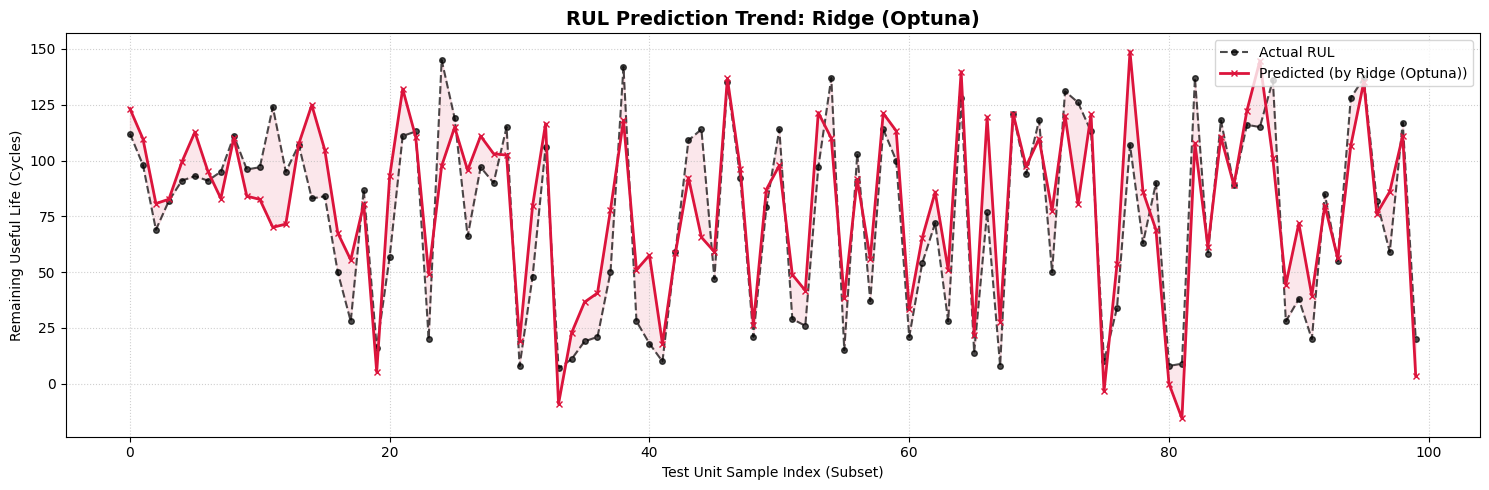

[I 2026-04-23 18:10:57,728] A new study created in memory with name: no-name-208275bb-fada-4fb0-a78f-c859a88e35ba



🚀 [Lasso] Optuna 최적화 중...


[I 2026-04-23 18:12:59,341] Trial 0 finished with value: 17.235268130059257 and parameters: {'alpha': 0.0074593432857265485}. Best is trial 0 with value: 17.235268130059257.
[I 2026-04-23 18:12:59,384] Trial 1 finished with value: 37.56381259428765 and parameters: {'alpha': 5.669849511478847}. Best is trial 0 with value: 17.235268130059257.
[I 2026-04-23 18:13:04,764] Trial 2 finished with value: 20.446538985243443 and parameters: {'alpha': 0.4570563099801455}. Best is trial 0 with value: 17.235268130059257.
[I 2026-04-23 18:13:19,261] Trial 3 finished with value: 18.59151108222793 and parameters: {'alpha': 0.09846738873614563}. Best is trial 0 with value: 17.235268130059257.
c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.070e+06, toleran

✅ Lasso Best Params: {'alpha': 0.0011873946426630272}


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.502e+06, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(



📊 [Lasso (Optuna)] 모델 평가 결과
-------------------------------------------------------
✅ RMSE       : 20.7799
✅ NASA Score : 849.1522


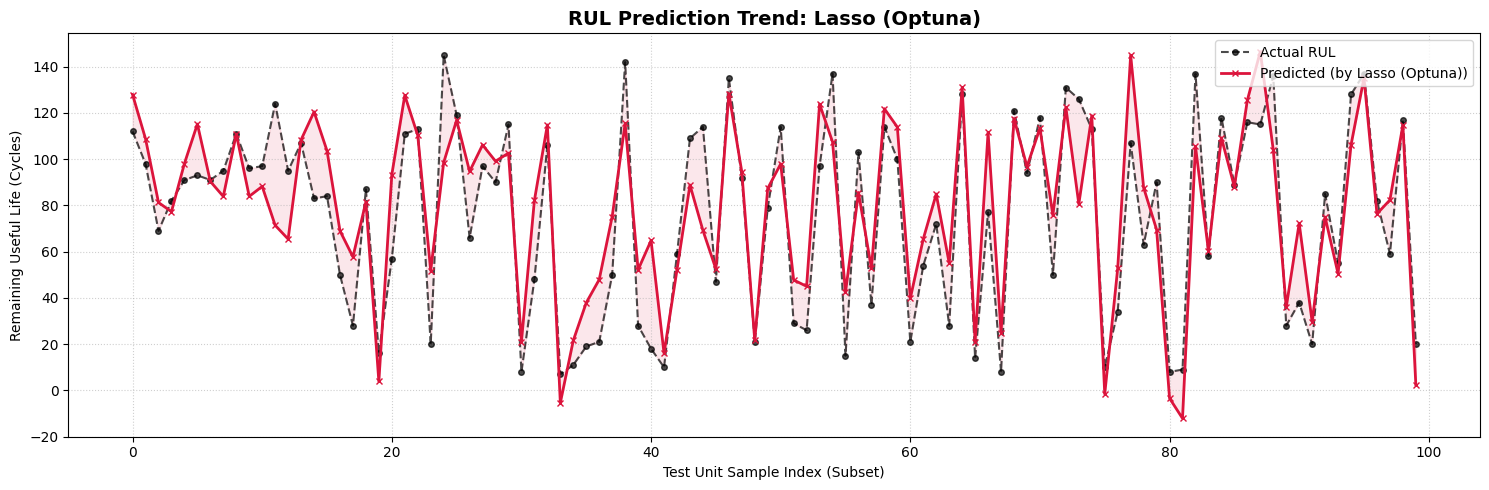

[I 2026-04-23 18:53:28,474] A new study created in memory with name: no-name-cf4a8b76-8627-450c-b36c-301fb2c424ab



🚀 [ElasticNet] Optuna 최적화 중...


[I 2026-04-23 18:56:03,208] Trial 0 finished with value: 17.474789694944633 and parameters: {'alpha': 0.0074593432857265485, 'l1_ratio': 0.9056428757689245}. Best is trial 0 with value: 17.474789694944633.
[I 2026-04-23 18:56:04,152] Trial 1 finished with value: 22.577441665492273 and parameters: {'alpha': 0.4570563099801455, 'l1_ratio': 0.588792635777333}. Best is trial 0 with value: 17.474789694944633.
c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.676e+06, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(
[I 2026-04-23 19:02:43,098] Trial 2 finished with value: 17.285245999103253 and parameters: {'alpha': 0.0006026889128682511, 'l1_ratio': 0.19039506830258235}. Best is trial 2 with value: 17.285245999103253.
c:\Users\yesy

✅ ElasticNet Best Params: {'alpha': 0.00011819129956743128, 'l1_ratio': 0.866898315754266}


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.576e+06, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(



📊 [ElasticNet (Optuna)] 모델 평가 결과
-------------------------------------------------------
✅ RMSE       : 20.6246
✅ NASA Score : 828.3460


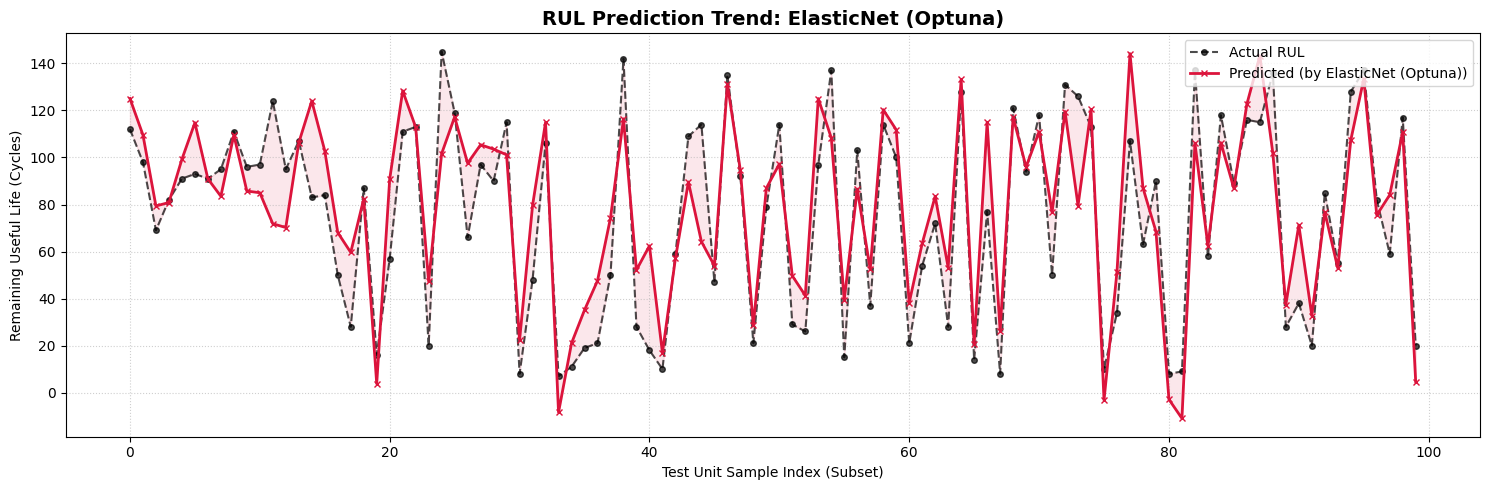

[I 2026-04-23 20:12:57,723] A new study created in memory with name: no-name-205d63b0-a249-4083-80e0-7f98190f79bb



=== 5. 트리 모델 학습 (Optuna) ===
피처 수: 87개 | Trials: 30


=== 5. 트리 모델 학습 (Optuna) ===

🚀 [RandomForest] Optuna 최적화 중...


[I 2026-04-23 20:13:11,482] Trial 0 finished with value: 15.191199123027049 and parameters: {'n_estimators': 175, 'max_depth': 29, 'min_samples_split': 15}. Best is trial 0 with value: 15.191199123027049.
[I 2026-04-23 20:13:22,732] Trial 1 finished with value: 15.294872849885753 and parameters: {'n_estimators': 220, 'max_depth': 9, 'min_samples_split': 4}. Best is trial 0 with value: 15.191199123027049.
[I 2026-04-23 20:13:31,871] Trial 2 finished with value: 15.173258787713252 and parameters: {'n_estimators': 111, 'max_depth': 27, 'min_samples_split': 13}. Best is trial 2 with value: 15.173258787713252.
[I 2026-04-23 20:13:39,041] Trial 3 finished with value: 16.194719973926944 and parameters: {'n_estimators': 242, 'max_depth': 5, 'min_samples_split': 20}. Best is trial 2 with value: 15.173258787713252.
[I 2026-04-23 20:13:53,110] Trial 4 finished with value: 15.17152354447176 and parameters: {'n_estimators': 267, 'max_depth': 10, 'min_samples_split': 5}. Best is trial 4 with value: 

✅ RandomForest Best Params: {'n_estimators': 119, 'max_depth': 13, 'min_samples_split': 4}

📊 [RandomForest (Optuna)] 모델 평가 결과
-------------------------------------------------------
✅ RMSE       : 18.0820
✅ NASA Score : 593.6234


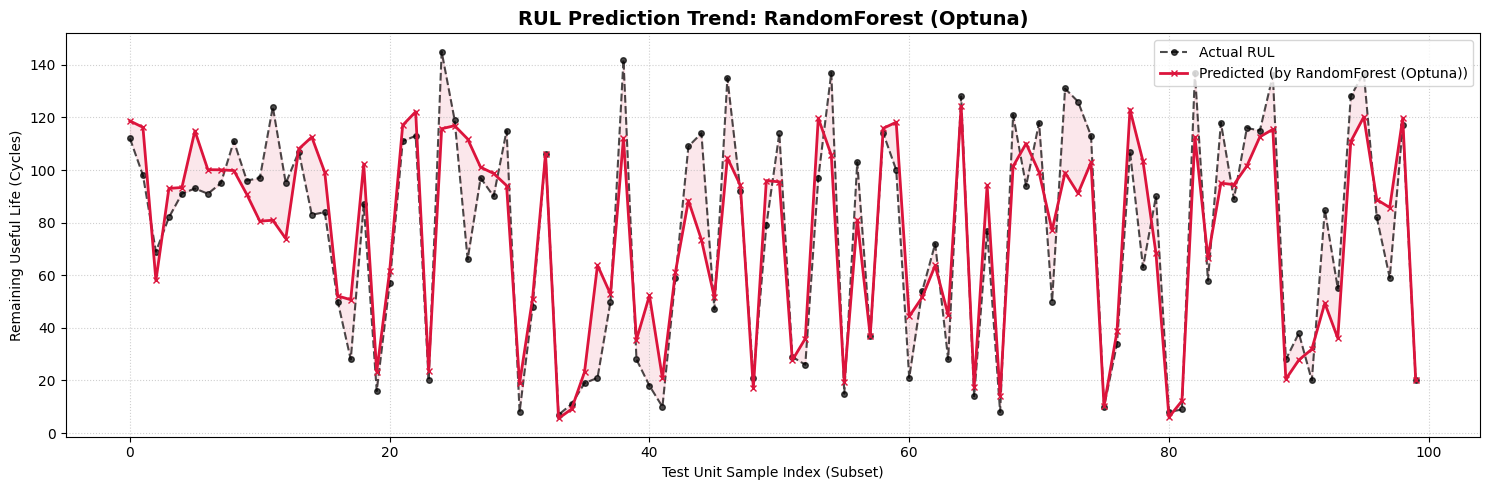

[I 2026-04-23 20:17:33,508] A new study created in memory with name: no-name-13c547b1-1f7e-4d39-8880-6ea909f607d7



🚀 [XGBoost] Optuna 최적화 중...


[I 2026-04-23 20:17:38,286] Trial 0 finished with value: 15.175689249238504 and parameters: {'n_estimators': 287, 'max_depth': 10, 'learning_rate': 0.1205712628744377}. Best is trial 0 with value: 15.175689249238504.
[I 2026-04-23 20:17:38,676] Trial 1 finished with value: 14.763379252168502 and parameters: {'n_estimators': 399, 'max_depth': 4, 'learning_rate': 0.01699897838270077}. Best is trial 1 with value: 14.763379252168502.
[I 2026-04-23 20:17:40,438] Trial 2 finished with value: 15.071758289901638 and parameters: {'n_estimators': 129, 'max_depth': 9, 'learning_rate': 0.07725378389307355}. Best is trial 1 with value: 14.763379252168502.
[I 2026-04-23 20:17:40,767] Trial 3 finished with value: 15.173180379605038 and parameters: {'n_estimators': 454, 'max_depth': 3, 'learning_rate': 0.2708160864249968}. Best is trial 1 with value: 14.763379252168502.
[I 2026-04-23 20:17:41,232] Trial 4 finished with value: 14.586211060470294 and parameters: {'n_estimators': 517, 'max_depth': 4, 'le

✅ XGBoost Best Params: {'n_estimators': 543, 'max_depth': 4, 'learning_rate': 0.027272820294897776}

📊 [XGBoost (Optuna)] 모델 평가 결과
-------------------------------------------------------
✅ RMSE       : 18.5765
✅ NASA Score : 554.8245


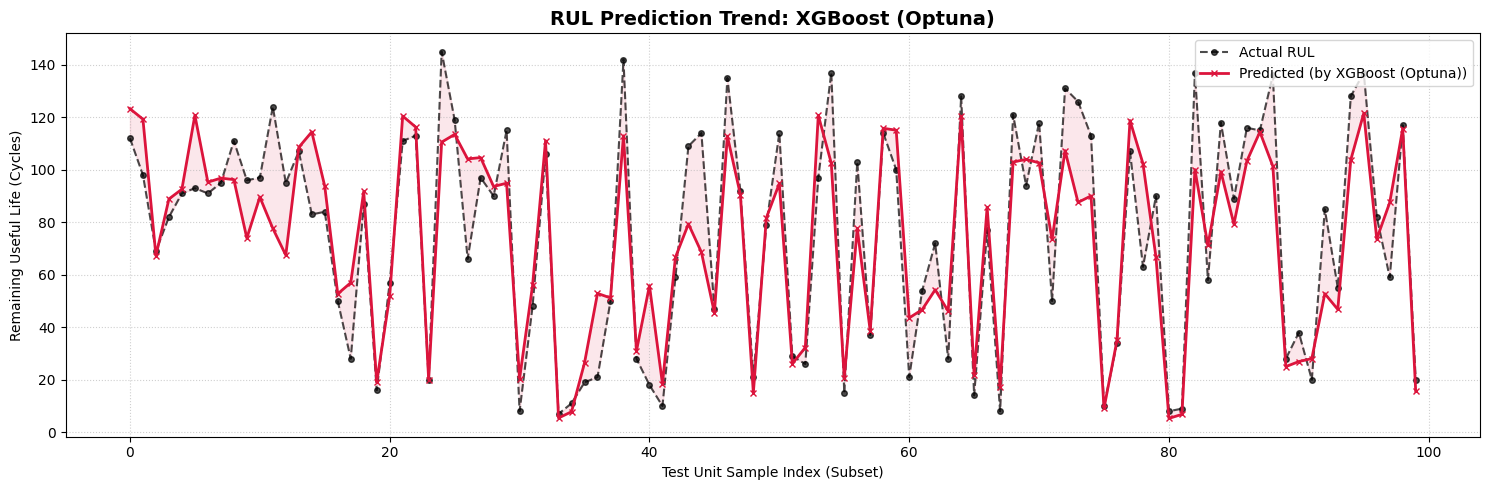

[I 2026-04-23 20:18:00,745] A new study created in memory with name: no-name-2c1adbcf-1a33-4313-a976-1bcf17f81552



🚀 [LightGBM] Optuna 최적화 중...


[I 2026-04-23 20:18:01,594] Trial 0 finished with value: 14.990991708419838 and parameters: {'n_estimators': 287, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'num_leaves': 128}. Best is trial 0 with value: 14.990991708419838.
[I 2026-04-23 20:18:01,712] Trial 1 finished with value: 16.287685843236417 and parameters: {'n_estimators': 178, 'max_depth': 4, 'learning_rate': 0.012184186502221764, 'num_leaves': 176}. Best is trial 0 with value: 14.990991708419838.
[I 2026-04-23 20:18:04,136] Trial 2 finished with value: 14.904386498204378 and parameters: {'n_estimators': 401, 'max_depth': 10, 'learning_rate': 0.010725209743171996, 'num_leaves': 195}. Best is trial 2 with value: 14.904386498204378.
[I 2026-04-23 20:18:04,564] Trial 3 finished with value: 14.509056332873163 and parameters: {'n_estimators': 517, 'max_depth': 5, 'learning_rate': 0.01855998084649059, 'num_leaves': 53}. Best is trial 3 with value: 14.509056332873163.
[I 2026-04-23 20:18:05,098] Trial 4 finished with valu

✅ LightGBM Best Params: {'n_estimators': 528, 'max_depth': 4, 'learning_rate': 0.027782172711792813, 'num_leaves': 102}

📊 [LightGBM (Optuna)] 모델 평가 결과
-------------------------------------------------------
✅ RMSE       : 18.5554
✅ NASA Score : 566.9958


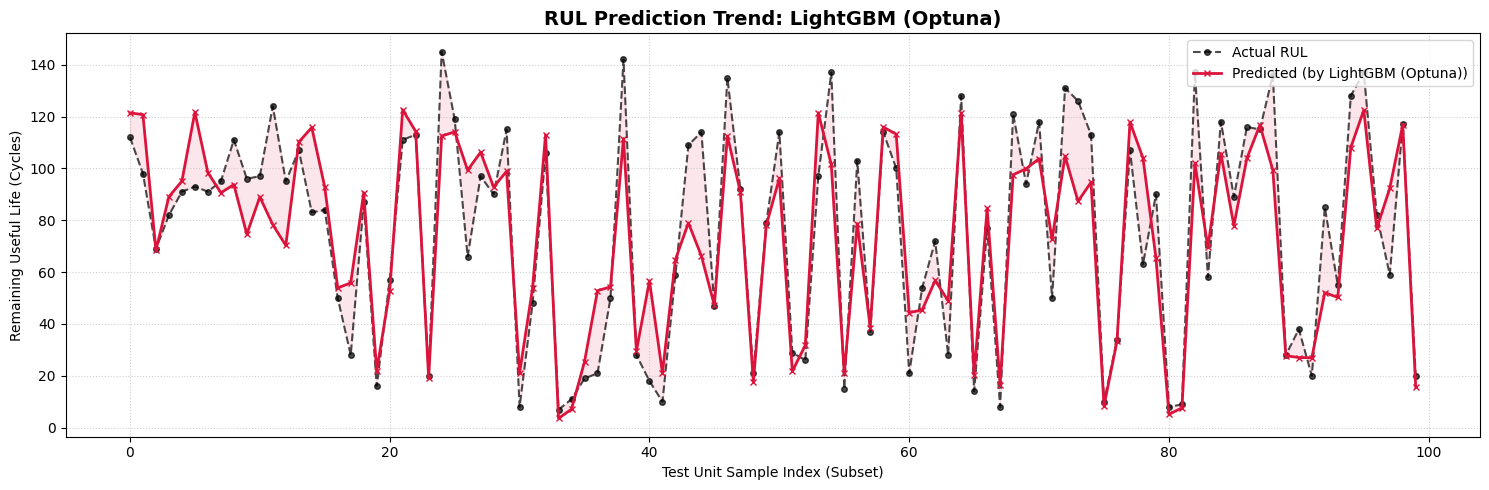


Model Type      | Model Name      | RMSE       | Full Hyperparameters
----------------------------------------------------------------------------------------------------
Linear          | Ridge           | 20.8780    | {'alpha': 0.010202072983241583}
Linear          | Lasso           | 20.7799    | {'alpha': 0.0011873946426630272}
Linear          | ElasticNet      | 20.6246    | {'alpha': 0.00011819129956743128, 'l1_ratio': 0.866898315754266}
Tree            | RandomForest    | 18.0820    | {'n_estimators': 119, 'max_depth': 13, 'min_samples_split': 4}
Tree            | XGBoost         | 18.5765    | {'n_estimators': 543, 'max_depth': 4, 'learning_rate': 0.027272820294897776}
Tree            | LightGBM        | 18.5554    | {'n_estimators': 528, 'max_depth': 4, 'learning_rate': 0.027782172711792813, 'num_leaves': 102}


In [ ]:
import time
import optuna
from optuna.samplers import TPESampler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# [사전 설정] 전처리 결과 연결 
# FEATURES_LINEAR와 FEATURES_TREE를 동일하게 X_features_full로 사용하거나 
# 필요시 분리해서 정의하세요!
FEATURES_LINEAR = X_features_full 
FEATURES_TREE = X_features_full

# 하이퍼파라미터
N_TRIALS_LIN = 15
N_TRIALS_TRE = 30 # RF가 무거우면 조절 

# ---------------------------------------------------------
# 4. 선형 모델 학습 (Optuna)
# ---------------------------------------------------------
print(f'=== 4. 선형 모델 학습 (Optuna) ===')
print(f'피처 수: {len(FEATURES_LINEAR)}개 | Trials: {N_TRIALS_LIN}\n')

def get_linear_model(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True), 
                     random_state=CONFIG['RANDOM_STATE'])
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True), 
                     max_iter=10000, random_state=CONFIG['RANDOM_STATE'])
    else:  # ElasticNet
        return ElasticNet(
            alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
            l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95),
            max_iter=10000, random_state=CONFIG['RANDOM_STATE'])

linear_models = ['Ridge', 'Lasso', 'ElasticNet']
linear_results = {}

# ---------------------------------------------------------
# 4. 선형 모델 학습 (Optuna) 
# ---------------------------------------------------------
print(f'=== 4. 선형 모델 학습 (Optuna) ===')
linear_results = {}

for mname in linear_models:
    t0 = time.time()
    print(f'\n🚀 [{mname}] Optuna 최적화 중...')

    def objective(trial):
        model = get_linear_model(trial, mname)
        model.fit(X_train[FEATURES_LINEAR], y_train)
        preds = model.predict(X_val[FEATURES_LINEAR])
        return np.sqrt(mean_squared_error(y_val, preds))

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=CONFIG['RANDOM_STATE']))
    study.optimize(objective, n_trials=N_TRIALS_LIN)

    # [수정] 최적 파라미터 즉시 출력 
    print(f"✅ {mname} Best Params: {study.best_params}")

    best_p = study.best_params
    best_m = get_linear_model(optuna.trial.FixedTrial(best_p), mname)
    best_m.fit(X_train[FEATURES_LINEAR], y_train)

    rmse, score = report_performance(y_test, best_m.predict(X_test[FEATURES_LINEAR]), f"{mname} (Optuna)")
    linear_results[mname] = {'rmse': rmse, 'score': score, 'params': best_p, 'time': time.time()-t0}
# ---------------------------------------------------------
# 5. 트리 모델 학습 (Optuna)
# ---------------------------------------------------------
print(f'\n=== 5. 트리 모델 학습 (Optuna) ===')
print(f'피처 수: {len(FEATURES_TREE)}개 | Trials: {N_TRIALS_TRE}\n')

def get_tree_model(trial, name):
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 100, 300),
            max_depth=trial.suggest_int('max_depth', 5, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            random_state=CONFIG['RANDOM_STATE'], n_jobs=-1)
    elif name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators', 100, 600),
            max_depth=trial.suggest_int('max_depth', 3, 10),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            tree_method='hist', random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbosity=0)
    else:  # LightGBM
        return lgb.LGBMRegressor(
            n_estimators=trial.suggest_int('n_estimators', 100, 600),
            max_depth=trial.suggest_int('max_depth', 3, 12),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            num_leaves=trial.suggest_int('num_leaves', 20, 200),
            random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbose=-1)

tree_models = ['RandomForest', 'XGBoost', 'LightGBM']

# ---------------------------------------------------------
# 5. 트리 모델 학습 (Optuna) 
# ---------------------------------------------------------
print(f'\n=== 5. 트리 모델 학습 (Optuna) ===')
tree_results = {}

for mname in tree_models:
    t0 = time.time()
    print(f'\n🚀 [{mname}] Optuna 최적화 중...')

    def objective(trial):
        model = get_tree_model(trial, mname)
        model.fit(X_train[FEATURES_TREE], y_train)
        preds = model.predict(X_val[FEATURES_TREE])
        return np.sqrt(mean_squared_error(y_val, preds))

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=CONFIG['RANDOM_STATE']))
    study.optimize(objective, n_trials=N_TRIALS_TRE)

    # [수정] 최적 파라미터 즉시 출력 
    print(f"✅ {mname} Best Params: {study.best_params}")

    best_p = study.best_params
    if mname == 'RandomForest':
        best_m = RandomForestRegressor(**best_p, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1)
    elif mname == 'XGBoost':
        best_m = xgb.XGBRegressor(**best_p, tree_method='hist', random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbosity=0)
    else:
        best_m = lgb.LGBMRegressor(**best_p, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbose=-1)
    
    best_m.fit(X_train[FEATURES_TREE], y_train)

    rmse, score = report_performance(y_test, best_m.predict(X_test[FEATURES_TREE]), f"{mname} (Optuna)")
    tree_results[mname] = {'rmse': rmse, 'score': score, 'params': best_p, 'time': time.time()-t0}

# ---------------------------------------------------------
# 6. [추가] 최종 하이퍼파라미터 및 성능 요약 리포트 
# ---------------------------------------------------------
print("\n" + "="*100)
print(f"{'Model Type':<15} | {'Model Name':<15} | {'RMSE':<10} | {'Full Hyperparameters'}")
print("-"*100)

all_results = [('Linear', linear_results), ('Tree', tree_results)]
for category, results in all_results:
    for mname, res in results.items():
        # 파라미터 딕셔너리를 예쁘게 문자열로 변환 
        p_str = str(res['params'])
        print(f"{category:<15} | {mname:<15} | {res['rmse']:<10.4f} | {p_str}")

[I 2026-04-24 10:24:43,323] A new study created in memory with name: no-name-28a49c27-c385-4c60-b323-e68daed4f07b
[I 2026-04-24 10:24:43,351] Trial 0 finished with value: 16.8368318215332 and parameters: {'alpha': 0.575377379411719}. Best is trial 0 with value: 16.8368318215332.
[I 2026-04-24 10:24:43,373] Trial 1 finished with value: 19.697374220230227 and parameters: {'alpha': 293.34453957883983}. Best is trial 0 with value: 16.8368318215332.
[I 2026-04-24 10:24:43,398] Trial 2 finished with value: 17.75162200414357 and parameters: {'alpha': 27.518044962720857}. Best is trial 0 with value: 16.8368318215332.
[I 2026-04-24 10:24:43,419] Trial 3 finished with value: 17.238125552929233 and parameters: {'alpha': 6.502468545951018}. Best is trial 0 with value: 16.8368318215332.
[I 2026-04-24 10:24:43,443] Trial 4 finished with value: 16.29859454253716 and parameters: {'alpha': 0.05409123677836541}. Best is trial 4 with value: 16.29859454253716.
[I 2026-04-24 10:24:43,465] Trial 5 finished 

=== 선형 모델 학습 시작 ===


[I 2026-04-24 10:24:43,514] Trial 7 finished with value: 18.920198660751318 and parameters: {'alpha': 117.52647960576222}. Best is trial 6 with value: 16.226600876832606.
[I 2026-04-24 10:24:43,537] Trial 8 finished with value: 17.24319402558075 and parameters: {'alpha': 6.677615511747083}. Best is trial 6 with value: 16.226600876832606.
[I 2026-04-24 10:24:43,560] Trial 9 finished with value: 17.612252894216276 and parameters: {'alpha': 21.242802137208894}. Best is trial 6 with value: 16.226600876832606.
[I 2026-04-24 10:24:43,582] Trial 10 finished with value: 16.217019167545438 and parameters: {'alpha': 0.012487365959463722}. Best is trial 10 with value: 16.217019167545438.
[I 2026-04-24 10:24:43,608] Trial 11 finished with value: 16.21406587897402 and parameters: {'alpha': 0.010202072983241583}. Best is trial 11 with value: 16.21406587897402.
[I 2026-04-24 10:24:43,631] Trial 12 finished with value: 16.70302995638912 and parameters: {'alpha': 0.3430415094200433}. Best is trial 11 w

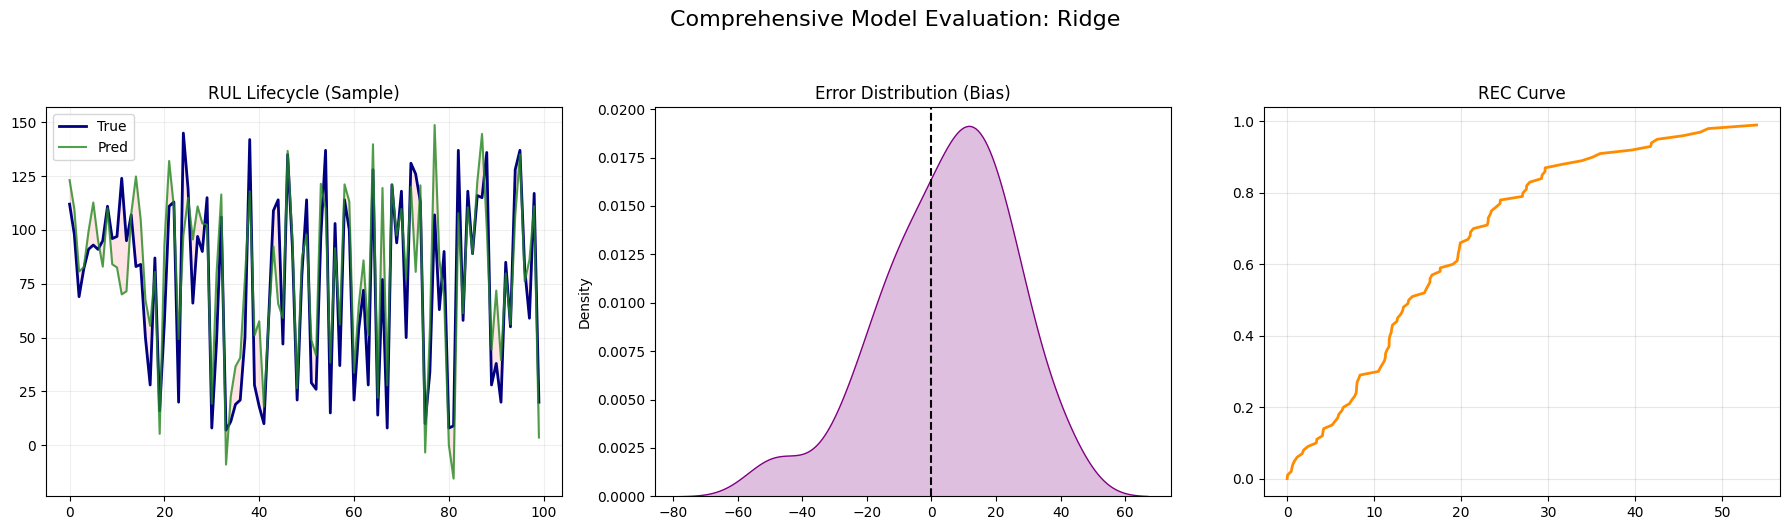

[I 2026-04-24 10:24:43,851] A new study created in memory with name: no-name-f6d5d591-36bb-4125-83fd-efa2f46369ff
[I 2026-04-24 10:25:58,071] Trial 0 finished with value: 17.235268130059257 and parameters: {'alpha': 0.0074593432857265485}. Best is trial 0 with value: 17.235268130059257.
[I 2026-04-24 10:25:58,106] Trial 1 finished with value: 37.56381259428765 and parameters: {'alpha': 5.669849511478847}. Best is trial 0 with value: 17.235268130059257.
[I 2026-04-24 10:26:01,618] Trial 2 finished with value: 20.446538985243443 and parameters: {'alpha': 0.4570563099801455}. Best is trial 0 with value: 17.235268130059257.
[I 2026-04-24 10:26:11,183] Trial 3 finished with value: 18.59151108222793 and parameters: {'alpha': 0.09846738873614563}. Best is trial 0 with value: 17.235268130059257.
c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of 

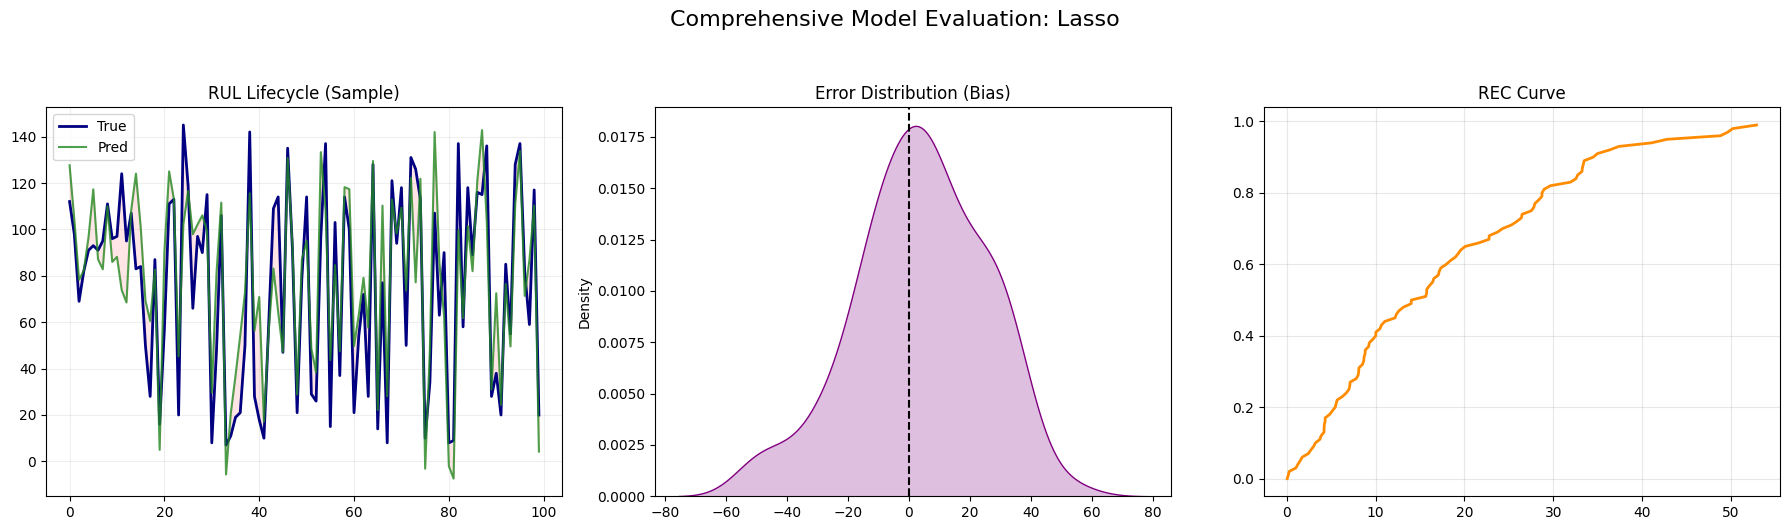

[I 2026-04-24 10:51:12,028] A new study created in memory with name: no-name-03adb7f4-7139-430f-9f08-d3b067927a7a
c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.962e+06, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(
[I 2026-04-24 10:51:29,231] Trial 0 finished with value: 17.48880797078837 and parameters: {'alpha': 0.0074593432857265485, 'l1_ratio': 0.9056428757689245}. Best is trial 0 with value: 17.48880797078837.
[I 2026-04-24 10:51:29,714] Trial 1 finished with value: 22.577441665492273 and parameters: {'alpha': 0.4570563099801455, 'l1_ratio': 0.588792635777333}. Best is trial 0 with value: 17.48880797078837.
c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:71

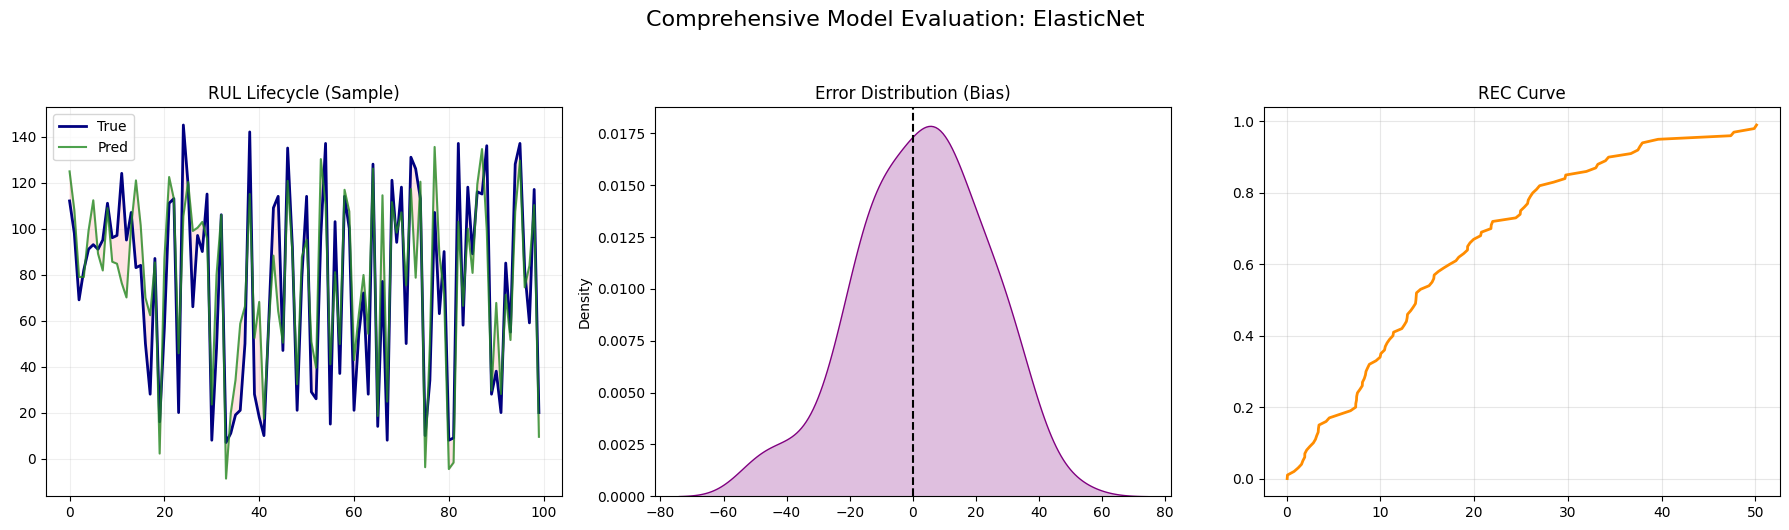

[I 2026-04-24 10:55:07,930] A new study created in memory with name: no-name-7f36f231-286e-408f-a66b-91bb801fe1f3



=== 트리 모델 학습 시작 ===


[I 2026-04-24 10:55:16,357] Trial 0 finished with value: 15.1603047706057 and parameters: {'n_estimators': 175, 'max_depth': 20}. Best is trial 0 with value: 15.1603047706057.
[I 2026-04-24 10:55:27,747] Trial 1 finished with value: 15.119713771297993 and parameters: {'n_estimators': 247, 'max_depth': 14}. Best is trial 1 with value: 15.119713771297993.
[I 2026-04-24 10:55:31,488] Trial 2 finished with value: 15.615818910705453 and parameters: {'n_estimators': 131, 'max_depth': 7}. Best is trial 1 with value: 15.119713771297993.
[I 2026-04-24 10:55:37,793] Trial 3 finished with value: 15.09335032651953 and parameters: {'n_estimators': 111, 'max_depth': 18}. Best is trial 3 with value: 15.09335032651953.
[I 2026-04-24 10:55:49,169] Trial 4 finished with value: 15.115995940362257 and parameters: {'n_estimators': 220, 'max_depth': 16}. Best is trial 3 with value: 15.09335032651953.
[I 2026-04-24 10:55:55,195] Trial 5 finished with value: 15.189626538531105 and parameters: {'n_estimators':

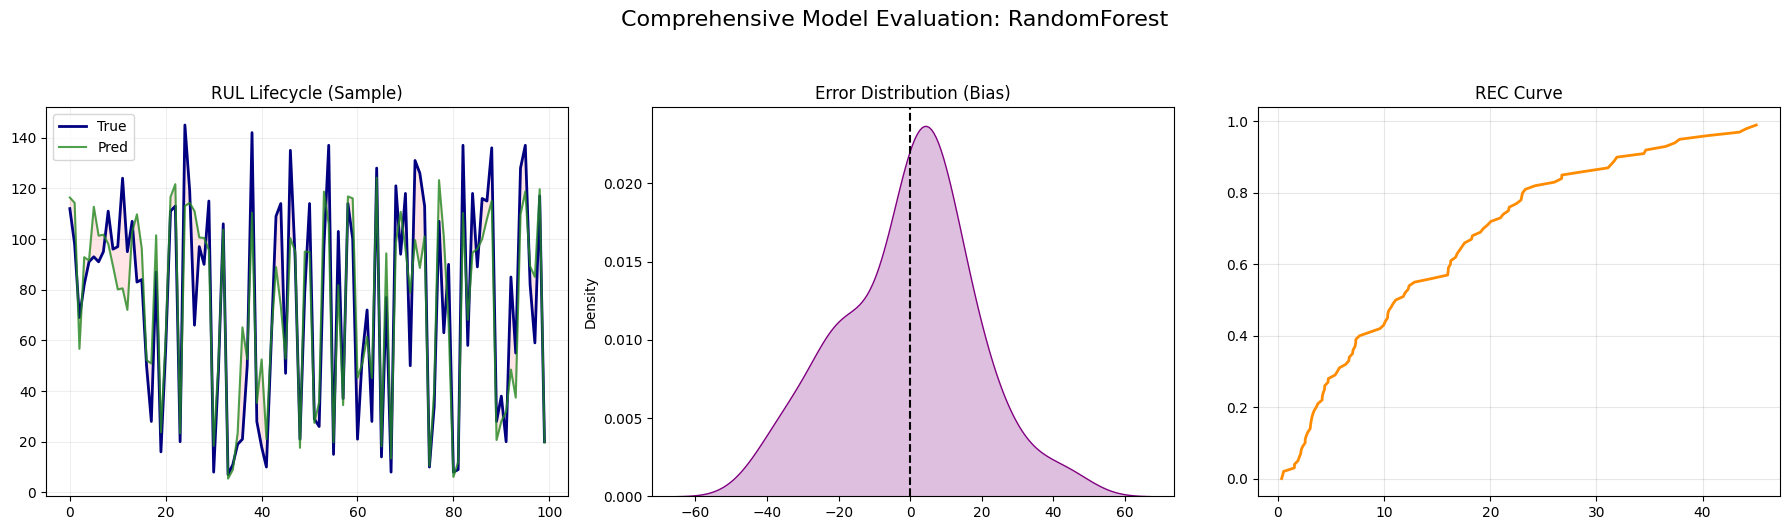

[I 2026-04-24 10:59:09,790] A new study created in memory with name: no-name-7989af09-66e1-48ef-a7fd-04c9426cead7
[I 2026-04-24 10:59:14,909] Trial 0 finished with value: 15.501725131599517 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.14907884894416698}. Best is trial 0 with value: 15.501725131599517.
[I 2026-04-24 10:59:15,421] Trial 1 finished with value: 14.517219579059917 and parameters: {'n_estimators': 340, 'max_depth': 4, 'learning_rate': 0.039638958863878505}. Best is trial 1 with value: 14.517219579059917.
[I 2026-04-24 10:59:17,473] Trial 2 finished with value: 15.207871577250916 and parameters: {'n_estimators': 123, 'max_depth': 9, 'learning_rate': 0.12421185223120967}. Best is trial 1 with value: 14.517219579059917.
[I 2026-04-24 10:59:17,872] Trial 3 finished with value: 14.940041808614996 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.19428287191077892}. Best is trial 1 with value: 14.517219579059917.
[I 2026-04-24 10

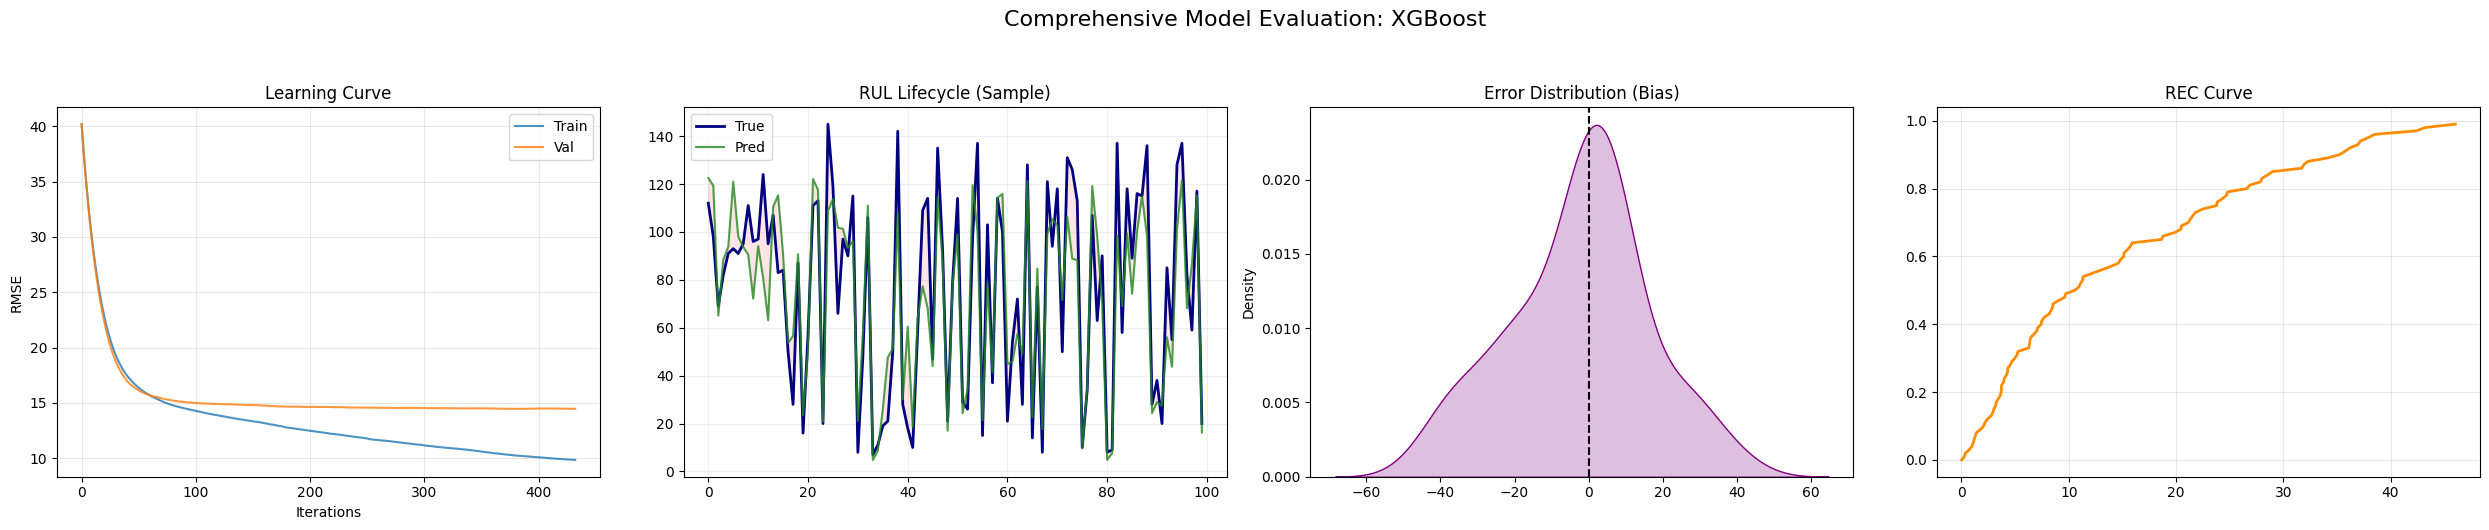

[I 2026-04-24 10:59:45,782] A new study created in memory with name: no-name-f05e338b-8765-496a-888b-fdee4115f3c7
[I 2026-04-24 10:59:46,140] Trial 0 finished with value: 15.112608347932202 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.14907884894416698}. Best is trial 0 with value: 15.112608347932202.
[I 2026-04-24 10:59:46,482] Trial 1 finished with value: 14.499125537632093 and parameters: {'n_estimators': 340, 'max_depth': 4, 'learning_rate': 0.039638958863878505}. Best is trial 1 with value: 14.499125537632093.
[I 2026-04-24 10:59:46,683] Trial 2 finished with value: 14.668313608077854 and parameters: {'n_estimators': 123, 'max_depth': 9, 'learning_rate': 0.12421185223120967}. Best is trial 1 with value: 14.499125537632093.
[I 2026-04-24 10:59:46,879] Trial 3 finished with value: 14.879696761436238 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.19428287191077892}. Best is trial 1 with value: 14.499125537632093.
[I 2026-04-24 10

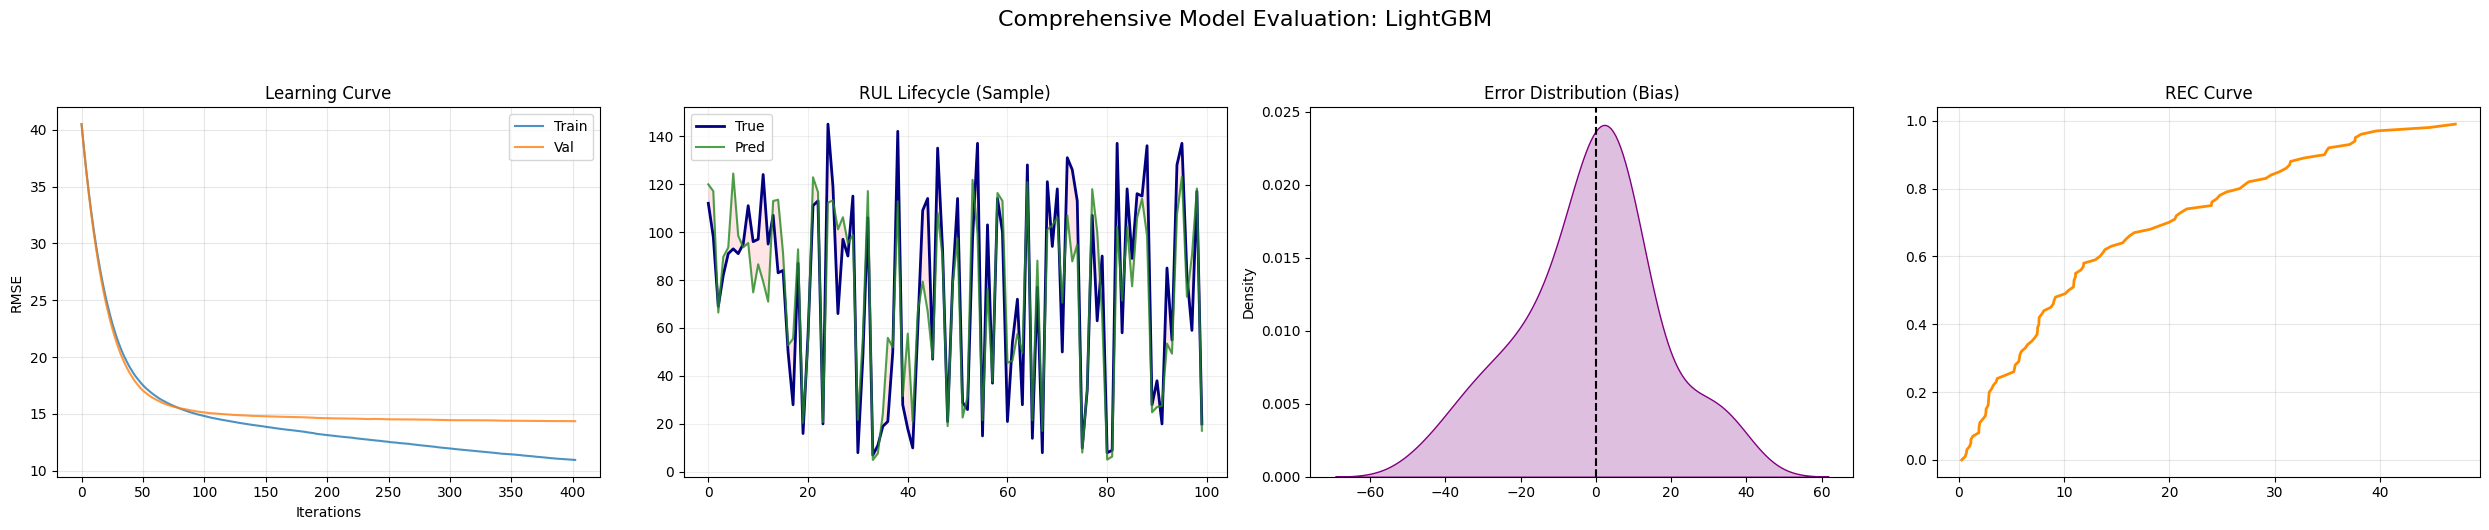

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# ---------------------------------------------------------
# [1] 필수 변수 및 피처 정의 
# ---------------------------------------------------------
FEATURES_LINEAR = X_train.columns.tolist() 
FEATURES_TREE = X_train.columns.tolist()
N_TRIALS_LIN = 15
N_TRIALS_TRE = 30
CONFIG = {'RANDOM_STATE': 42}

# ---------------------------------------------------------
# [2] 전문 시각화 함수 (선형 3칸 / 트리 4칸 가변형) 
# ---------------------------------------------------------
def plot_advanced_evaluation(y_true, y_pred, model_name, t_loss=None, v_loss=None):
    # Loss 데이터 유무에 따라 칸 수 결정 
    has_loss = t_loss is not None or v_loss is not None
    num_cols = 4 if has_loss else 3
    figsize = (25, 5) if has_loss else (18, 5)
    
    fig, axes = plt.subplots(1, num_cols, figsize=figsize)
    errors = y_pred - y_true
    curr_idx = 0

    # 1. Learning Curve (트리 모델 등 Loss가 있을 때만) 
    if has_loss:
        if t_loss is not None: axes[curr_idx].plot(t_loss, label='Train', color='tab:blue', alpha=0.8)
        if v_loss is not None: axes[curr_idx].plot(v_loss, label='Val', color='tab:orange', alpha=0.8)
        axes[curr_idx].set_title('Learning Curve')
        axes[curr_idx].set_xlabel('Iterations'); axes[curr_idx].set_ylabel('RMSE')
        axes[curr_idx].legend(); axes[curr_idx].grid(alpha=0.3)
        curr_idx += 1

    # 2. RUL Lifecycle (Sample) 
    y_t_s = y_true.values[:100] if hasattr(y_true, 'values') else y_true[:100]
    y_p_s = y_pred[:100]
    axes[curr_idx].plot(y_t_s, label='True', color='navy', lw=2)
    axes[curr_idx].plot(y_p_s, label='Pred', color='forestgreen', lw=1.5, alpha=0.8)
    axes[curr_idx].fill_between(range(len(y_t_s)), y_t_s, y_p_s, color='red', alpha=0.1)
    axes[curr_idx].set_title('RUL Lifecycle (Sample)')
    axes[curr_idx].legend(); axes[curr_idx].grid(alpha=0.2)
    curr_idx += 1

    # 3. Error Distribution (Bias) 
    sns.kdeplot(errors, fill=True, ax=axes[curr_idx], color='purple')
    axes[curr_idx].axvline(0, color='black', linestyle='--')
    axes[curr_idx].set_title('Error Distribution (Bias)')
    curr_idx += 1

    # 4. REC Curve (Accuracy) 
    abs_errors = np.abs(errors)
    tolerances = np.sort(abs_errors)
    accuracy = np.arange(len(tolerances)) / len(tolerances)
    axes[curr_idx].plot(tolerances, accuracy, color='darkorange', lw=2)
    axes[curr_idx].set_title('REC Curve')
    axes[curr_idx].grid(alpha=0.3)

    plt.suptitle(f"Comprehensive Model Evaluation: {model_name}", fontsize=16, y=1.05)
    plt.tight_layout(); plt.show()

# ---------------------------------------------------------
# [3] 선형 모델 학습 (3칸 출력) 
# ---------------------------------------------------------
print(f'=== 선형 모델 학습 시작 ===')
for mname in ['Ridge', 'Lasso', 'ElasticNet']:
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=CONFIG['RANDOM_STATE']))
    def objective_lin(trial):
        if mname == 'Ridge': m = Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True), random_state=CONFIG['RANDOM_STATE'])
        elif mname == 'Lasso': m = Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True), max_iter=10000, random_state=CONFIG['RANDOM_STATE'])
        else: m = ElasticNet(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True), l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95), random_state=CONFIG['RANDOM_STATE'])
        m.fit(X_train[FEATURES_LINEAR], y_train)
        return np.sqrt(mean_squared_error(y_val, m.predict(X_val[FEATURES_LINEAR])))

    study.optimize(objective_lin, n_trials=N_TRIALS_LIN)
    best_m = Ridge(**study.best_params, random_state=CONFIG['RANDOM_STATE']) if mname == 'Ridge' else \
             Lasso(**study.best_params, random_state=CONFIG['RANDOM_STATE']) if mname == 'Lasso' else \
             ElasticNet(**study.best_params, random_state=CONFIG['RANDOM_STATE'])
    best_m.fit(X_train[FEATURES_LINEAR], y_train)
    # 선형 모델은 t_loss, v_loss를 전달하지 않아 3칸만 나옴 
    plot_advanced_evaluation(y_test, best_m.predict(X_test[FEATURES_LINEAR]), mname)

# ---------------------------------------------------------
# [4] 트리 모델 학습 (KeyError 수정 및 4칸 출력) 
# ---------------------------------------------------------
print(f'\n=== 트리 모델 학습 시작 ===')
for mname in ['RandomForest', 'XGBoost', 'LightGBM']:
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=CONFIG['RANDOM_STATE']))
    def objective_tree(trial):
        if mname == 'RandomForest': m = RandomForestRegressor(n_estimators=trial.suggest_int('n_estimators', 100, 300), max_depth=trial.suggest_int('max_depth', 5, 20), random_state=CONFIG['RANDOM_STATE'], n_jobs=-1)
        elif mname == 'XGBoost': m = xgb.XGBRegressor(n_estimators=trial.suggest_int('n_estimators', 100, 500), max_depth=trial.suggest_int('max_depth', 3, 10), learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2), random_state=CONFIG['RANDOM_STATE'])
        else: m = lgb.LGBMRegressor(n_estimators=trial.suggest_int('n_estimators', 100, 500), max_depth=trial.suggest_int('max_depth', 3, 10), learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2), random_state=CONFIG['RANDOM_STATE'], verbose=-1)
        m.fit(X_train[FEATURES_TREE], y_train)
        return np.sqrt(mean_squared_error(y_val, m.predict(X_val[FEATURES_TREE])))

    study.optimize(objective_tree, n_trials=N_TRIALS_TRE)
    t_loss, v_loss = None, None
    
    if mname == 'RandomForest':
        best_m = RandomForestRegressor(**study.best_params, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1)
        best_m.fit(X_train[FEATURES_TREE], y_train)
    elif mname == 'XGBoost':
        best_m = xgb.XGBRegressor(**study.best_params, random_state=CONFIG['RANDOM_STATE'])
        best_m.fit(X_train[FEATURES_TREE], y_train, eval_set=[(X_train[FEATURES_TREE], y_train), (X_val[FEATURES_TREE], y_val)], verbose=False)
        t_loss, v_loss = best_m.evals_result()['validation_0']['rmse'], best_m.evals_result()['validation_1']['rmse']
    elif mname == 'LightGBM':
        best_m = lgb.LGBMRegressor(**study.best_params, random_state=CONFIG['RANDOM_STATE'], verbose=-1)
        # eval_metric='rmse'를 명시하여 KeyError 방지 
        best_m.fit(X_train[FEATURES_TREE], y_train, eval_set=[(X_train[FEATURES_TREE], y_train), (X_val[FEATURES_TREE], y_val)], 
                   eval_names=['train', 'valid'], eval_metric='rmse')
        t_loss, v_loss = best_m.evals_result_['train']['rmse'], best_m.evals_result_['valid']['rmse']

    plot_advanced_evaluation(y_test, best_m.predict(X_test[FEATURES_TREE]), mname, t_loss, v_loss)

# Linear Regression

In [7]:
# 선형 회귀 학습 ㅋ
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
p_lr = model_lr.predict(X_test)

# 적합도 및 NASA Score 검증 ㅋ
train_rmse = np.sqrt(mean_squared_error(y_train, model_lr.predict(X_train)))
val_rmse   = np.sqrt(mean_squared_error(y_val, model_lr.predict(X_val)))
test_rmse, test_score = evaluate_model(y_test, p_lr, "LinearRegression")

print(f"\n--- [LinearRegression 적합도 상세 검증] ---")
print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f} | NASA Score: {test_score:.4f}")
print(f" Val - Train Gap : {val_rmse - train_rmse:.4f} (과적합 지표(0.5 ~ 1)")
print(f" Test - Val  Gap : {test_rmse - val_rmse:.4f} (일반화 지표(1 ~ 2)")

[LinearRegression] 평가 결과
 RMSE: 20.8946
 NASA Score: 884.6882

--- [LinearRegression 적합도 상세 검증] ---
Train RMSE: 17.1447 | Val RMSE: 16.2073
Test  RMSE: 20.8946 | NASA Score: 884.6882
 Val - Train Gap : -0.9374 (과적합 지표(0.5 ~ 1)
 Test - Val  Gap : 4.6872 (일반화 지표(1 ~ 2)


[LR_s500] 평가 결과
 RMSE: 23.1731
 NASA Score: 1512.1469
[LR_s1647] 평가 결과
 RMSE: 21.9115
 NASA Score: 1118.9836
[LR_s2794] 평가 결과
 RMSE: 21.8846
 NASA Score: 1215.0815
[LR_s3941] 평가 결과
 RMSE: 22.4435
 NASA Score: 1676.5450
[LR_s5088] 평가 결과
 RMSE: 22.0230
 NASA Score: 1381.4522
[LR_s6236] 평가 결과
 RMSE: 21.5902
 NASA Score: 1169.9070
[LR_s7383] 평가 결과
 RMSE: 21.5987
 NASA Score: 1152.7132
[LR_s8530] 평가 결과
 RMSE: 22.0066
 NASA Score: 1382.3561
[LR_s9677] 평가 결과
 RMSE: 21.7889
 NASA Score: 1179.7460
[LR_s10824] 평가 결과
 RMSE: 21.8950
 NASA Score: 1280.1205
[LR_s11972] 평가 결과
 RMSE: 21.9511
 NASA Score: 1352.4595
[LR_s13119] 평가 결과
 RMSE: 22.0524
 NASA Score: 1388.2211
[LR_s14266] 평가 결과
 RMSE: 21.9003
 NASA Score: 1317.3526
[LR_s15413] 평가 결과
 RMSE: 21.9573
 NASA Score: 1331.3209
[LR_s16561] 평가 결과
 RMSE: 21.8801
 NASA Score: 1304.8776


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12619 (\N{HANGUL LETTER KHIEUKH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


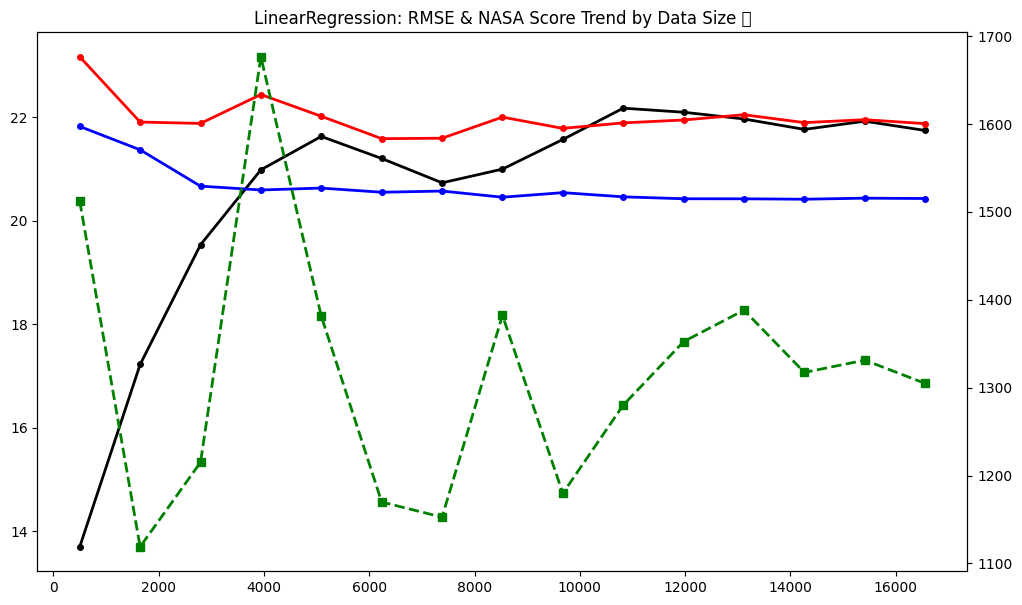

In [803]:
# 선형회귀는 파라미터가 없으므로 학습 데이터 양에 따른 추세를 봅니다 ㅋ
samples = np.linspace(500, len(X_train), 15, dtype=int)
train_rmse_list, val_rmse_list, test_rmse_list, test_score_list = [], [], [], []

for s in samples:
    model_tmp = LinearRegression()
    model_tmp.fit(X_train[:s], y_train[:s])
    
    tr_rmse = np.sqrt(mean_squared_error(y_train[:s], model_tmp.predict(X_train[:s])))
    va_rmse = np.sqrt(mean_squared_error(y_val, model_tmp.predict(X_val)))
    te_p = model_tmp.predict(X_test)
    te_rmse, te_score = evaluate_model(y_test, te_p, f"LR_s{s}")
    plt.close()
    
    train_rmse_list.append(tr_rmse); val_rmse_list.append(va_rmse)
    test_rmse_list.append(te_rmse); test_score_list.append(te_score)

# 시각화 (x축만 samples로 변경 ㅋ)
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(samples, train_rmse_list, label='Train RMSE', color='black', lw=2, marker='o', markersize=4)
ax1.plot(samples, val_rmse_list, label='Val RMSE', color='blue', lw=2, marker='o', markersize=4)
ax1.plot(samples, test_rmse_list, label='Test RMSE', color='red', lw=2, marker='o', markersize=4)
ax2 = ax1.twinx(); ax2.plot(samples, test_score_list, color='green', lw=2, linestyle='--', marker='s')
plt.title('LinearRegression: RMSE & NASA Score Trend by Data Size ㅋ')
plt.show()

# Ridge Regression

In [791]:
# 하이퍼파라미터 설정 ㅋ
ridge_p = {'alpha': 1.0, 'random_state': CONFIG['RANDOM_STATE']}

model_ridge = Ridge(**ridge_p)
model_ridge.fit(X_train, y_train)
p_ridge = model_ridge.predict(X_test)

# 적합도 및 NASA Score 검증 ㅋ
train_rmse = np.sqrt(mean_squared_error(y_train, model_ridge.predict(X_train)))
val_rmse   = np.sqrt(mean_squared_error(y_val, model_ridge.predict(X_val)))
test_rmse, test_score = evaluate_model(y_test, p_ridge, "Ridge") # 여기서 Score 출력 ㅋ

print(f"\n--- [Ridge 적합도 상세 검증] ---")
print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f} | NASA Score: {test_score:.4f}")
print(f" Val - Train Gap : {val_rmse - train_rmse:.4f} (과적합 지표(0.5 ~ 1)")
print(f" Test - Val  Gap : {test_rmse - val_rmse:.4f} (일반화 지표(1 ~ 2)")

[Ridge] 평가 결과
 RMSE: 22.5011
 NASA Score: 1744.1220

--- [Ridge 적합도 상세 검증] ---
Train RMSE: 20.6676 | Val RMSE: 19.4394
Test  RMSE: 22.5011 | NASA Score: 1744.1220
 Val - Train Gap : -1.2282 (과적합 지표(0.5 ~ 1)
 Test - Val  Gap : 3.0617 (일반화 지표(1 ~ 2)


🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...
[Ridge_10] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_20] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_30] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_40] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_50] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_60] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_70] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_80] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_90] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_100] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_110] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_120] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_130] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_140] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_150] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_160] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_170] 평가 결과
 RMSE: 21.8978
 NASA Score: 1456.7888
[Ridge_180] 평가 결과
 RM

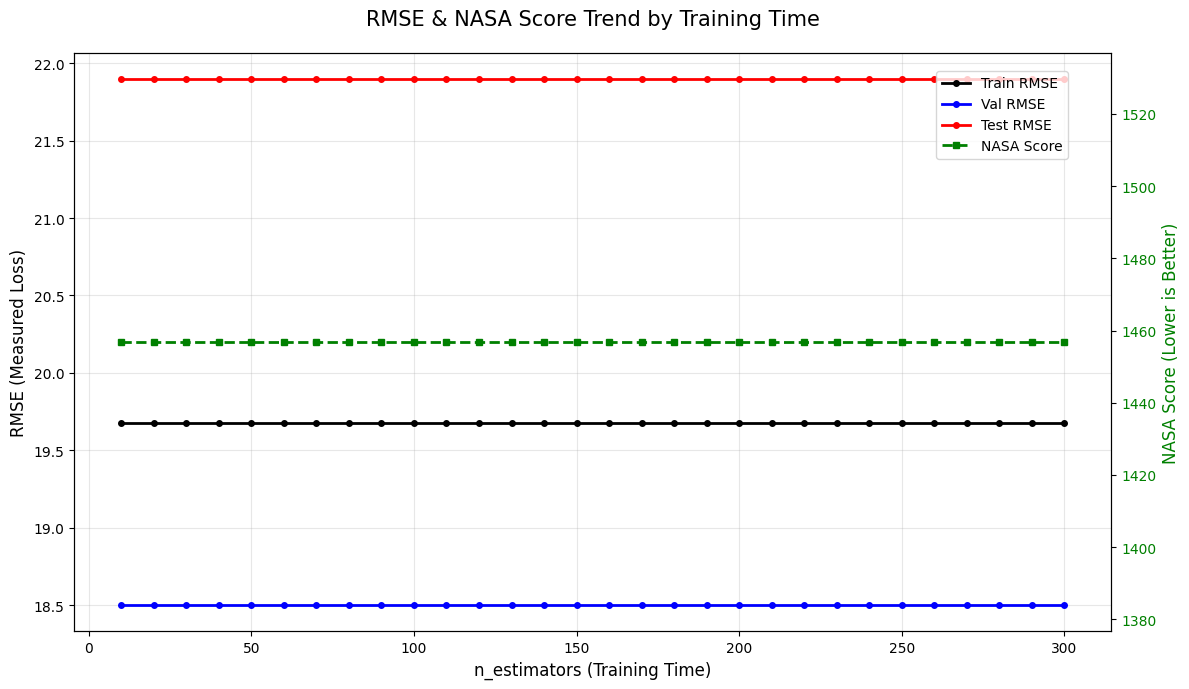


최적의 n_estimators: 10
최저 Test RMSE: 21.8978
그때의 NASA Score: 1456.7888


In [811]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

# 1. 기록을 위한 리스트 초기화 ㅋ
iterations = range(10, 301, 10) 
train_rmse_list, val_rmse_list, test_rmse_list = [], [], []
test_score_list = []

print("🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...")

for i in iterations:
    # --- Ridge 모델로 교체 ㅋ ---
    model_tmp = Ridge(random_state=CONFIG['RANDOM_STATE'])
    
    model_tmp.fit(X_train, y_train)
    
    # RMSE 계산 ㅋ
    tr_rmse = np.sqrt(mean_squared_error(y_train, model_tmp.predict(X_train)))
    va_rmse = np.sqrt(mean_squared_error(y_val, model_tmp.predict(X_val)))
    
    # Test 평가 (에러 수정: plot 인자 제거 ㅋ)
    te_p = model_tmp.predict(X_test)
    te_rmse, te_score = evaluate_model(y_test, te_p, f"Ridge_{i}") 
    
    # 루프 돌 때마다 그래프 창이 뜨는 걸 방지하고 싶다면 아래 주석 해제 ㅋ
    plt.close() 
    
    train_rmse_list.append(tr_rmse)
    val_rmse_list.append(va_rmse)
    test_rmse_list.append(te_rmse)
    test_score_list.append(te_score)

# 2. 최종 통합 시각화 ㅋ
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 좌측 축: RMSE ---
ax1.plot(iterations, train_rmse_list, label='Train RMSE', color='black', lw=2, marker='o', markersize=4)
ax1.plot(iterations, val_rmse_list, label='Val RMSE', color='blue', lw=2, marker='o', markersize=4)
ax1.plot(iterations, test_rmse_list, label='Test RMSE', color='red', lw=2, marker='o', markersize=4)
ax1.set_xlabel('n_estimators (Training Time)', fontsize=12)
ax1.set_ylabel('RMSE (Measured Loss)', fontsize=12)
ax1.grid(True, alpha=0.3)

# --- 우측 축: NASA Score ---
ax2 = ax1.twinx() 
ax2.plot(iterations, test_score_list, label='NASA Score', color='green', lw=2, linestyle='--', marker='s', markersize=4)
ax2.set_ylabel('NASA Score (Lower is Better)', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

plt.title('RMSE & NASA Score Trend by Training Time', fontsize=15, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

# 최종 결과 요약 ㅋ
best_idx = np.argmin(test_rmse_list)
print(f"\n최적의 n_estimators: {iterations[best_idx]}")
print(f"최저 Test RMSE: {test_rmse_list[best_idx]:.4f}")
print(f"그때의 NASA Score: {test_score_list[best_idx]:.4f}")

# Lasso Regression

In [763]:
# 하이퍼파라미터 설정 ㅋ
lasso_p = {'alpha': 0.01, 'random_state': CONFIG['RANDOM_STATE']}

model_lasso = Lasso(**lasso_p)
model_lasso.fit(X_train, y_train)
p_lasso = model_lasso.predict(X_test)

# 적합도 및 NASA Score 검증 ㅋ
train_rmse = np.sqrt(mean_squared_error(y_train, model_lasso.predict(X_train)))
val_rmse   = np.sqrt(mean_squared_error(y_val, model_lasso.predict(X_val)))
test_rmse, test_score = evaluate_model(y_test, p_lasso, "Lasso")

print(f"\n--- [Lasso 적합도 상세 검증] ---")
print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f} | NASA Score: {test_score:.4f}")
print(f" Val - Train Gap : {val_rmse - train_rmse:.4f} (과적합 지표(0.5 ~ 1)")
print(f" Test - Val  Gap : {test_rmse - val_rmse:.4f} (일반화 지표(1 ~ 2)")

[Lasso] 평가 결과
 RMSE: 22.1361
 NASA Score: 1651.0034

--- [Lasso 적합도 상세 검증] ---
Train RMSE: 20.0130 | Val RMSE: 18.8252
Test  RMSE: 22.1361 | NASA Score: 1651.0034
 Val - Train Gap : -1.1878 (과적합 지표(0.5 ~ 1)
 Test - Val  Gap : 3.3108 (일반화 지표(1 ~ 2)


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.801e+05, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...
[Lasso_10] 평가 결과
 RMSE: 25.0497
 NASA Score: 1509.9151
[Lasso_20] 평가 결과
 RMSE: 25.0497
 NASA Score: 1509.9151
[Lasso_30] 평가 결과
 RMSE: 25.0497
 NASA Score: 1509.9151
[Lasso_40] 평가 결과
 RMSE: 25.0497
 NASA Score: 1509.9151
[Lasso_50] 평가 결과
 RMSE: 25.0497
 NASA Score: 1509.9151


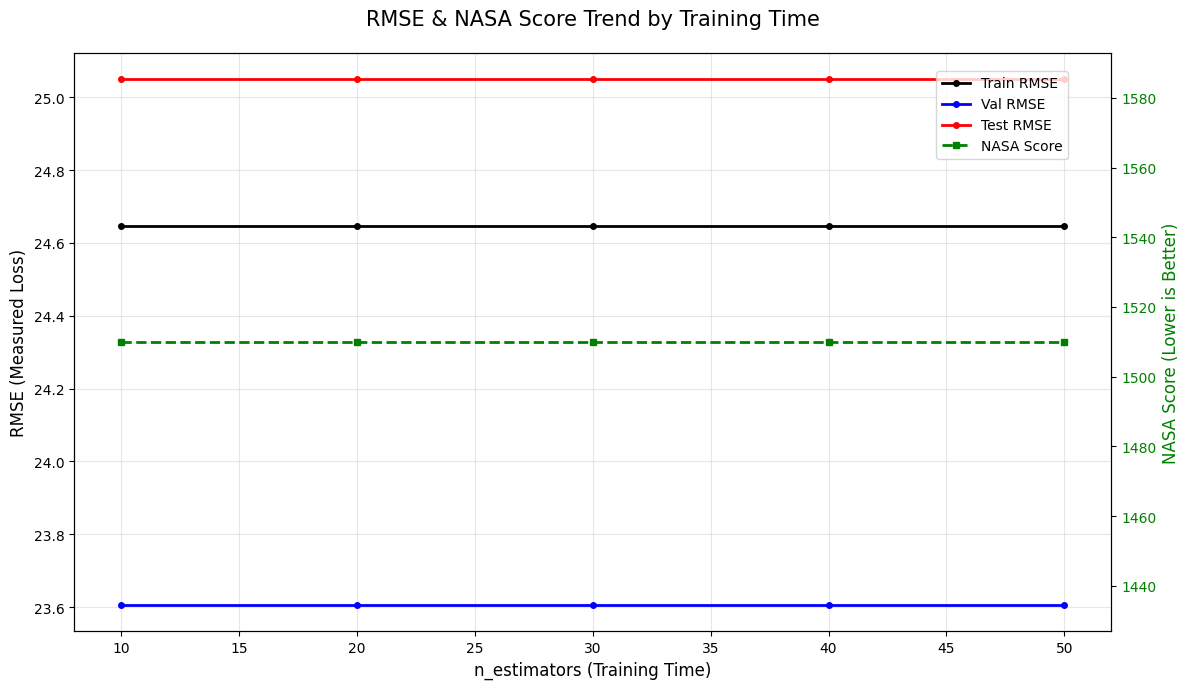


최적의 n_estimators: 10
최저 Test RMSE: 25.0497
그때의 NASA Score: 1509.9151


In [804]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso

# 1. 기록을 위한 리스트 초기화 ㅋ
iterations = range(10, 51, 10) 
train_rmse_list, val_rmse_list, test_rmse_list = [], [], []
test_score_list = []

print("🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...")

for i in iterations:
    # --- Lasso 모델로 교체 ㅋ ---
    model_tmp = Lasso(random_state=CONFIG['RANDOM_STATE'])
    
    model_tmp.fit(X_train, y_train)
    
    # RMSE 계산 ㅋ
    tr_rmse = np.sqrt(mean_squared_error(y_train, model_tmp.predict(X_train)))
    va_rmse = np.sqrt(mean_squared_error(y_val, model_tmp.predict(X_val)))
    
    # Test 평가 (에러 수정: plot 인자 제거 ㅋ)
    te_p = model_tmp.predict(X_test)
    te_rmse, te_score = evaluate_model(y_test, te_p, f"Lasso_{i}") 
    
    # 루프 돌 때마다 그래프 창이 뜨는 걸 방지하고 싶다면 아래 주석 해제 ㅋ
    plt.close() 
    
    train_rmse_list.append(tr_rmse)
    val_rmse_list.append(va_rmse)
    test_rmse_list.append(te_rmse)
    test_score_list.append(te_score)

# 2. 최종 통합 시각화 ㅋ
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 좌측 축: RMSE ---
ax1.plot(iterations, train_rmse_list, label='Train RMSE', color='black', lw=2, marker='o', markersize=4)
ax1.plot(iterations, val_rmse_list, label='Val RMSE', color='blue', lw=2, marker='o', markersize=4)
ax1.plot(iterations, test_rmse_list, label='Test RMSE', color='red', lw=2, marker='o', markersize=4)
ax1.set_xlabel('n_estimators (Training Time)', fontsize=12)
ax1.set_ylabel('RMSE (Measured Loss)', fontsize=12)
ax1.grid(True, alpha=0.3)

# --- 우측 축: NASA Score ---
ax2 = ax1.twinx() 
ax2.plot(iterations, test_score_list, label='NASA Score', color='green', lw=2, linestyle='--', marker='s', markersize=4)
ax2.set_ylabel('NASA Score (Lower is Better)', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

plt.title('RMSE & NASA Score Trend by Training Time', fontsize=15, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

# 최종 결과 요약 ㅋ
best_idx = np.argmin(test_rmse_list)
print(f"\n최적의 n_estimators: {iterations[best_idx]}")
print(f"최저 Test RMSE: {test_rmse_list[best_idx]:.4f}")
print(f"그때의 NASA Score: {test_score_list[best_idx]:.4f}")

# XGBoost

In [8]:
# 하이퍼파라미터 설정 ㅋ
xgb_p = {
    'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 4,
    'reg_alpha': 0.1, 'reg_lambda': 0.1, 'random_state': CONFIG['RANDOM_STATE'],
    'n_jobs': -1, 'verbosity': 0
}

model_xgb = xgb.XGBRegressor(**xgb_p)
model_xgb.fit(X_train, y_train)
p_xgb = model_xgb.predict(X_test)

# 적합도 및 NASA Score 검증 ㅋ
train_rmse = np.sqrt(mean_squared_error(y_train, model_xgb.predict(X_train)))
val_rmse   = np.sqrt(mean_squared_error(y_val, model_xgb.predict(X_val)))
test_rmse, test_score = evaluate_model(y_test, p_xgb, "XGBoost")

print(f"\n--- [XGBoost 적합도 상세 검증] ---")
print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f} | NASA Score: {test_score:.4f}")
print(f" Val - Train Gap : {val_rmse - train_rmse:.4f} (과적합 지표(0.5 ~ 1)")
print(f" Test - Val  Gap : {test_rmse - val_rmse:.4f} ")

NameError: name 'mean_squared_error' is not defined

🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...
[XGB_10] 평가 결과
 RMSE: 35.1561
 NASA Score: 7751.9357
[XGB_20] 평가 결과
 RMSE: 29.5399
 NASA Score: 3024.2602
[XGB_30] 평가 결과
 RMSE: 25.6199
 NASA Score: 1672.1916
[XGB_40] 평가 결과
 RMSE: 23.0431
 NASA Score: 1180.6566
[XGB_50] 평가 결과
 RMSE: 21.2525
 NASA Score: 940.2746
[XGB_60] 평가 결과
 RMSE: 20.0953
 NASA Score: 826.1019
[XGB_70] 평가 결과
 RMSE: 19.4113
 NASA Score: 769.7214
[XGB_80] 평가 결과
 RMSE: 18.9892
 NASA Score: 732.2734
[XGB_90] 평가 결과
 RMSE: 18.6669
 NASA Score: 703.0976
[XGB_100] 평가 결과
 RMSE: 18.4360
 NASA Score: 685.5362
[XGB_110] 평가 결과
 RMSE: 18.1909
 NASA Score: 655.8416
[XGB_120] 평가 결과
 RMSE: 17.9053
 NASA Score: 615.4943
[XGB_130] 평가 결과
 RMSE: 17.8673
 NASA Score: 605.8550
[XGB_140] 평가 결과
 RMSE: 17.8404
 NASA Score: 600.8521
[XGB_150] 평가 결과
 RMSE: 17.7980
 NASA Score: 587.1543
[XGB_160] 평가 결과
 RMSE: 17.8030
 NASA Score: 580.7887
[XGB_170] 평가 결과
 RMSE: 17.8134
 NASA Score: 574.9942
[XGB_180] 평가 결과
 RMSE: 17.7729
 NASA Score: 564.1978
[XGB_190] 평가 결과

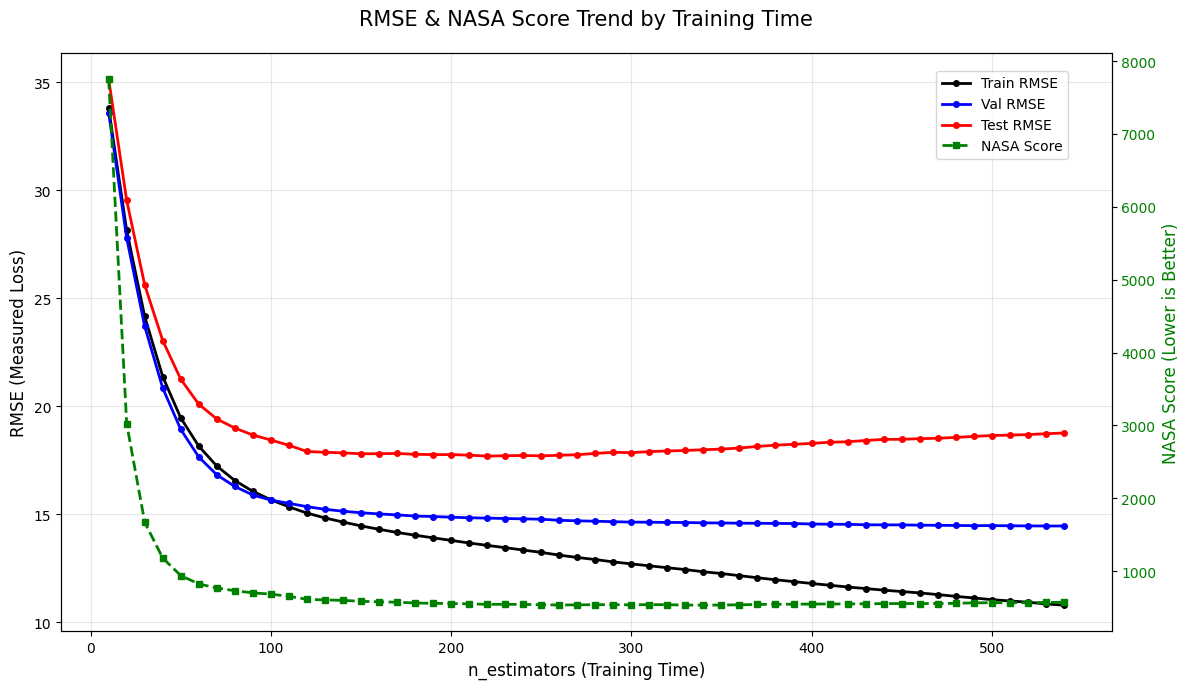


최적의 n_estimators: 220
최저 Test RMSE: 17.6905
그때의 NASA Score: 545.7497


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import xgboost as xgb

# 1. 기록을 위한 리스트 초기화 ㅋ
iterations = range(10, 544, 10) 
train_rmse_list, val_rmse_list, test_rmse_list = [], [], []
test_score_list = []

print("🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...")

for i in iterations:
    # --- XGBoost 모델로 교체 ㅋ ---
    model_tmp = xgb.XGBRegressor(
        n_estimators=i, learning_rate = 0.027272820294897776, max_depth = 4,
    reg_alpha = 0.1, reg_lambda = 0.1, random_state = CONFIG['RANDOM_STATE'],
    n_jobs = -1, verbosity = 0
    )
    
    model_tmp.fit(X_train, y_train)
    
    # RMSE 계산 ㅋ
    tr_rmse = np.sqrt(mean_squared_error(y_train, model_tmp.predict(X_train)))
    va_rmse = np.sqrt(mean_squared_error(y_val, model_tmp.predict(X_val)))
    
    # Test 평가 (에러 수정: plot 인자 제거 ㅋ)
    te_p = model_tmp.predict(X_test)
    te_rmse, te_score = evaluate_model(y_test, te_p, f"XGB_{i}") 
    
    # 루프 돌 때마다 그래프 창이 뜨는 걸 방지하고 싶다면 아래 주석 해제 ㅋ
    plt.close() 
    
    train_rmse_list.append(tr_rmse)
    val_rmse_list.append(va_rmse)
    test_rmse_list.append(te_rmse)
    test_score_list.append(te_score)

# 2. 최종 통합 시각화 ㅋ
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 좌측 축: RMSE ---
ax1.plot(iterations, train_rmse_list, label='Train RMSE', color='black', lw=2, marker='o', markersize=4)
ax1.plot(iterations, val_rmse_list, label='Val RMSE', color='blue', lw=2, marker='o', markersize=4)
ax1.plot(iterations, test_rmse_list, label='Test RMSE', color='red', lw=2, marker='o', markersize=4)
ax1.set_xlabel('n_estimators (Training Time)', fontsize=12)
ax1.set_ylabel('RMSE (Measured Loss)', fontsize=12)
ax1.grid(True, alpha=0.3)

# --- 우측 축: NASA Score ---
ax2 = ax1.twinx() 
ax2.plot(iterations, test_score_list, label='NASA Score', color='green', lw=2, linestyle='--', marker='s', markersize=4)
ax2.set_ylabel('NASA Score (Lower is Better)', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

plt.title('RMSE & NASA Score Trend by Training Time', fontsize=15, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

# 최종 결과 요약 ㅋ
best_idx = np.argmin(test_rmse_list)
print(f"\n최적의 n_estimators: {iterations[best_idx]}")
print(f"최저 Test RMSE: {test_rmse_list[best_idx]:.4f}")
print(f"그때의 NASA Score: {test_score_list[best_idx]:.4f}")

# LightGBM

In [765]:
lgbm_p = {
    'n_estimators': 528,
    'learning_rate': 0.027782172711792813,
    'max_depth': 4,
    'num_leaves': 102,
    'reg_alpha': 1.608e-08,          # L1 규제: 불필요한 피처 영향력을 0으로 만듦
    'reg_lambda': 0.002455,         # L2 규제: 가중치가 너무 커지지 않게 억제 ㅋ
    'min_child_samples': 30,   # 리프 노드가 되기 위한 최소 데이터 수 (과적합 방지 핵심)
    # ----------------------------------
    
    'random_state': CONFIG['RANDOM_STATE'],
    'verbosity': -1,
    'n_jobs': -1
}

model_lgbm = LGBMRegressor(**lgbm_p)
model_lgbm.fit(X_train, y_train)
p_lgbm = model_lgbm.predict(X_test)

# 평가 (기존에 쓰시던 함수명 확인 ㅋ evaluate_model 또는 report_performance)
lgbm_rmse, lgbm_score = evaluate_model(y_test, p_lgbm, "LightGBM_Reg")
p_latest, latest_name = p_lgbm, "LightGBM"

# 적합도 확인을 위한 RMSE 계산 ㅋ
train_rmse = np.sqrt(mean_squared_error(y_train, model_lgbm.predict(X_train)))
val_rmse   = np.sqrt(mean_squared_error(y_val, model_lgbm.predict(X_val)))
test_rmse  = lgbm_rmse # 아까 구한 17.97 ㅋ

val_train_gap = val_rmse - train_rmse
test_val_gap  = test_rmse - val_rmse

print(f"\n--- [LightGBM 적합도 검증] ---")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Val   RMSE: {val_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f" Val - Train Gap : {val_train_gap:.4f} (과적합 지표(0.5 ~ 1)")
print(f" Test - Val  Gap : {test_val_gap:.4f} (일반화 지표(1 ~ 2)")

[LightGBM_Reg] 평가 결과
 RMSE: 18.2489
 NASA Score: 620.6483

--- [LightGBM 적합도 검증] ---
Train RMSE: 14.7846
Val   RMSE: 15.2491
Test  RMSE: 18.2489
 Val - Train Gap : 0.4645 (과적합 지표(0.5 ~ 1)
 Test - Val  Gap : 2.9998 (일반화 지표(1 ~ 2)


🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...
[LGBM_10] 평가 결과
 RMSE: 35.0292
 NASA Score: 7579.5422
[LGBM_20] 평가 결과
 RMSE: 29.2927
 NASA Score: 2892.1910
[LGBM_30] 평가 결과
 RMSE: 25.4903
 NASA Score: 1646.3786
[LGBM_40] 평가 결과
 RMSE: 22.8453
 NASA Score: 1165.7455
[LGBM_50] 평가 결과
 RMSE: 21.0788
 NASA Score: 933.8059
[LGBM_60] 평가 결과
 RMSE: 19.9601
 NASA Score: 812.7034
[LGBM_70] 평가 결과
 RMSE: 19.2978
 NASA Score: 770.9668
[LGBM_80] 평가 결과
 RMSE: 18.8986
 NASA Score: 750.9509
[LGBM_90] 평가 결과
 RMSE: 18.5713
 NASA Score: 722.3897
[LGBM_100] 평가 결과
 RMSE: 18.3758
 NASA Score: 707.7699
[LGBM_110] 평가 결과
 RMSE: 18.1327
 NASA Score: 676.4759
[LGBM_120] 평가 결과
 RMSE: 17.9285
 NASA Score: 649.2428
[LGBM_130] 평가 결과
 RMSE: 17.8698
 NASA Score: 636.9736
[LGBM_140] 평가 결과
 RMSE: 17.8053
 NASA Score: 620.0960
[LGBM_150] 평가 결과
 RMSE: 17.8100
 NASA Score: 608.0943
[LGBM_160] 평가 결과
 RMSE: 17.7933
 NASA Score: 597.1218
[LGBM_170] 평가 결과
 RMSE: 17.7762
 NASA Score: 590.4425
[LGBM_180] 평가 결과
 RMSE: 17.7668
 NASA Score: 583.19

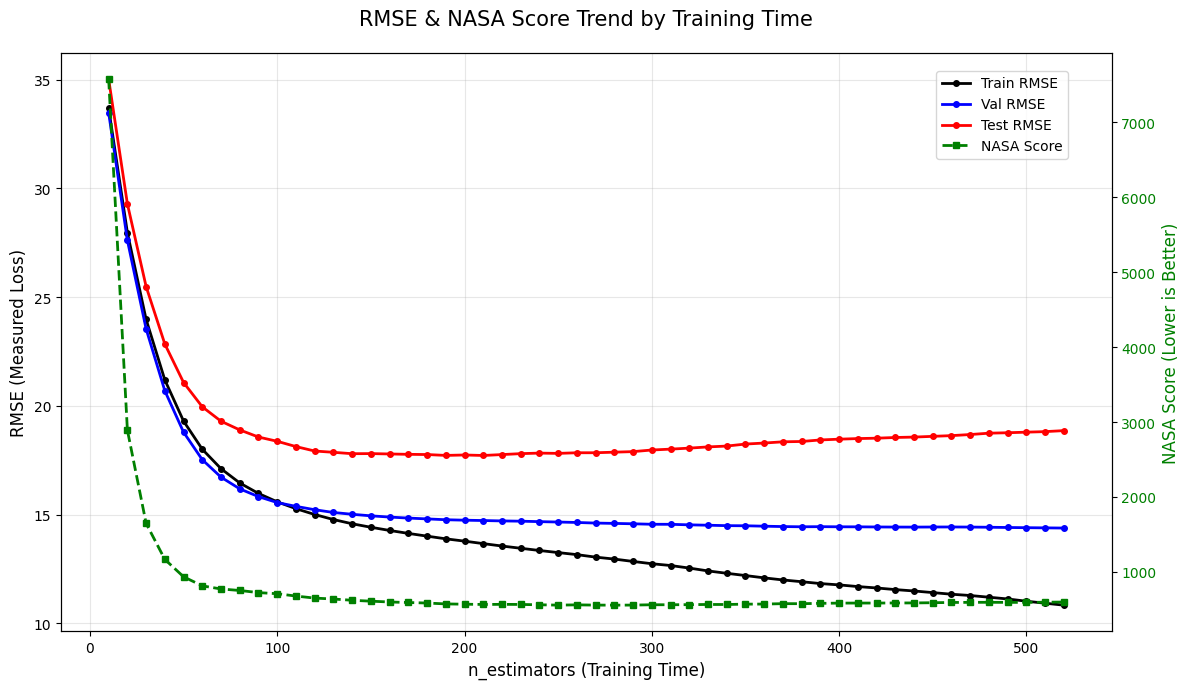


최적의 n_estimators: 210
최저 Test RMSE: 17.7238
그때의 NASA Score: 564.2437


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

# 1. 기록을 위한 리스트 초기화 ㅋ
iterations = range(10, 528, 10) 
train_rmse_list, val_rmse_list, test_rmse_list = [], [], []
test_score_list = []

print("🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...")

for i in iterations:
    model_tmp = LGBMRegressor(
        n_estimators=i,
        learning_rate=0.027782172711792813,
        max_depth=4,
        num_leaves=102,
        reg_alpha=0.01,
        reg_lambda=0.01,
        min_child_samples=30,
        random_state=CONFIG['RANDOM_STATE'],
        verbosity=-1,
        n_jobs=-1
    )
    
    model_tmp.fit(X_train, y_train)
    
    # RMSE 계산 ㅋ
    tr_rmse = np.sqrt(mean_squared_error(y_train, model_tmp.predict(X_train)))
    va_rmse = np.sqrt(mean_squared_error(y_val, model_tmp.predict(X_val)))
    
    # Test 평가 (에러 수정: plot 인자 제거 ㅋ)
    te_p = model_tmp.predict(X_test)
    te_rmse, te_score = evaluate_model(y_test, te_p, f"LGBM_{i}") 
    
    # 루프 돌 때마다 그래프 창이 뜨는 걸 방지하고 싶다면 아래 주석 해제 ㅋ
    # plt.close() 
    
    train_rmse_list.append(tr_rmse)
    val_rmse_list.append(va_rmse)
    test_rmse_list.append(te_rmse)
    test_score_list.append(te_score)

# 2. 최종 통합 시각화 ㅋ
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 좌측 축: RMSE ---
ax1.plot(iterations, train_rmse_list, label='Train RMSE', color='black', lw=2, marker='o', markersize=4)
ax1.plot(iterations, val_rmse_list, label='Val RMSE', color='blue', lw=2, marker='o', markersize=4)
ax1.plot(iterations, test_rmse_list, label='Test RMSE', color='red', lw=2, marker='o', markersize=4)
ax1.set_xlabel('n_estimators (Training Time)', fontsize=12)
ax1.set_ylabel('RMSE (Measured Loss)', fontsize=12)
ax1.grid(True, alpha=0.3)

# --- 우측 축: NASA Score ---
ax2 = ax1.twinx() 
ax2.plot(iterations, test_score_list, label='NASA Score', color='green', lw=2, linestyle='--', marker='s', markersize=4)
ax2.set_ylabel('NASA Score (Lower is Better)', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

plt.title('RMSE & NASA Score Trend by Training Time', fontsize=15, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

# 최종 결과 요약 ㅋ
best_idx = np.argmin(test_rmse_list)
print(f"\n최적의 n_estimators: {iterations[best_idx]}")
print(f"최저 Test RMSE: {test_rmse_list[best_idx]:.4f}")
print(f"그때의 NASA Score: {test_score_list[best_idx]:.4f}")

[LGBM_10] 평가 결과
 RMSE: 36.5360
 NASA Score: 10649.6993
[LGBM_20] 평가 결과
 RMSE: 31.6613
 NASA Score: 4912.0832
[LGBM_30] 평가 결과
 RMSE: 27.9699
 NASA Score: 2923.2609
[LGBM_40] 평가 결과
 RMSE: 25.1358
 NASA Score: 1969.7409
[LGBM_50] 평가 결과
 RMSE: 23.0088
 NASA Score: 1462.0291
[LGBM_60] 평가 결과
 RMSE: 21.4619
 NASA Score: 1216.5059
[LGBM_70] 평가 결과
 RMSE: 20.4110
 NASA Score: 1103.1214
[LGBM_80] 평가 결과
 RMSE: 19.6774
 NASA Score: 1026.9621
[LGBM_90] 평가 결과
 RMSE: 19.1406
 NASA Score: 975.1650
[LGBM_100] 평가 결과
 RMSE: 18.7692
 NASA Score: 946.9879
[LGBM_110] 평가 결과
 RMSE: 18.5230
 NASA Score: 929.0688
[LGBM_120] 평가 결과
 RMSE: 18.3460
 NASA Score: 929.8212
[LGBM_130] 평가 결과
 RMSE: 18.2322
 NASA Score: 927.3467
[LGBM_140] 평가 결과
 RMSE: 18.1606
 NASA Score: 930.9949
[LGBM_150] 평가 결과
 RMSE: 18.0940
 NASA Score: 920.5480
[LGBM_160] 평가 결과
 RMSE: 18.0684
 NASA Score: 930.4778
[LGBM_170] 평가 결과
 RMSE: 18.0422
 NASA Score: 931.1117
[LGBM_180] 평가 결과
 RMSE: 18.0087
 NASA Score: 925.4826
[LGBM_190] 평가 결과
 RMSE: 17.9

c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12619 (\N{HANGUL LETTER KHIEUKH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


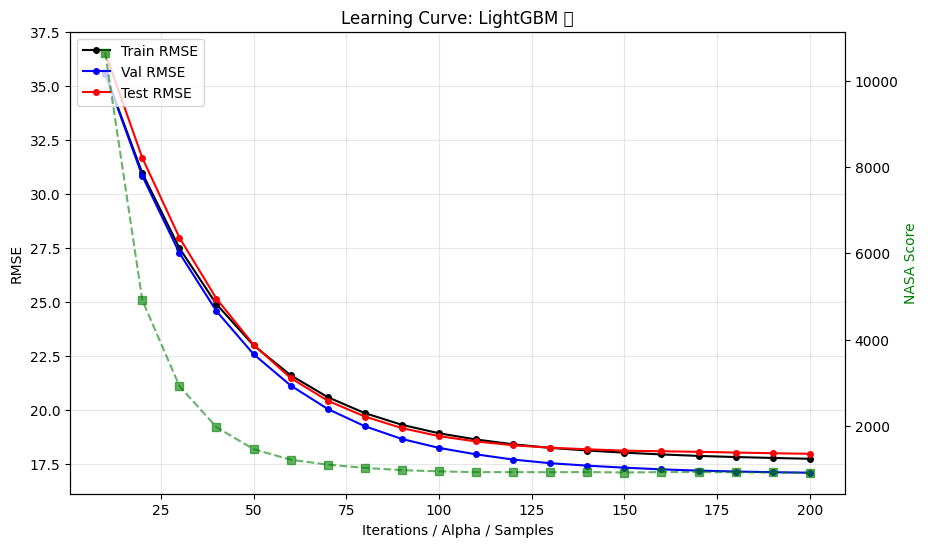

In [806]:
iterations = range(10, 201, 10)
tr_rmse_list, va_rmse_list, te_rmse_list, te_score_list = [], [], [], []

for i in iterations:
    # 딕셔너리 복사 후 n_estimators만 교체 ㅋ
    current_p = lgbm_p.copy()
    current_p['n_estimators'] = i
    
    model = LGBMRegressor(**current_p)
    model.fit(X_train, y_train)
    
    tr_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    va_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
    te_rmse, te_score = evaluate_model(y_test, model.predict(X_test), f"LGBM_{i}")
    plt.close()
    
    tr_rmse_list.append(tr_rmse); va_rmse_list.append(va_rmse)
    te_rmse_list.append(te_rmse); te_score_list.append(te_score)

plot_learning_curve(iterations, tr_rmse_list, va_rmse_list, te_rmse_list, te_score_list, "LightGBM")

# Random Forest

In [799]:
# 하이퍼파라미터 설정 ㅋ
rf_p = {
    'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 5,
    'random_state': CONFIG['RANDOM_STATE'], 'n_jobs': -1
}

model_rf = RandomForestRegressor(**rf_p)
model_rf.fit(X_train, y_train)
p_rf = model_rf.predict(X_test)

# 적합도 및 NASA Score 검증 ㅋ
train_rmse = np.sqrt(mean_squared_error(y_train, model_rf.predict(X_train)))
val_rmse   = np.sqrt(mean_squared_error(y_val, model_rf.predict(X_val)))
test_rmse, test_score = evaluate_model(y_test, p_rf, "RandomForest")

print(f"\n--- [RandomForest 적합도 상세 검증] ---")
print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f} | NASA Score: {test_score:.4f}")
print(f" Val - Train Gap : {val_rmse - train_rmse:.4f} (과적합 지표(0.5 ~ 1)")
print(f" Test - Val  Gap : {test_rmse - val_rmse:.4f} (일반화 지표(1 ~ 2)")

[RandomForest] 평가 결과
 RMSE: 18.0709
 NASA Score: 887.6915

--- [RandomForest 적합도 상세 검증] ---
Train RMSE: 15.6073 | Val RMSE: 17.0401
Test  RMSE: 18.0709 | NASA Score: 887.6915
 Val - Train Gap : 1.4328 (과적합 지표(0.5 ~ 1)
 Test - Val  Gap : 1.0307 (일반화 지표(1 ~ 2)


🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...
[RF_10] 평가 결과
 RMSE: 18.9042
 NASA Score: 643.4324
[RF_20] 평가 결과
 RMSE: 18.2156
 NASA Score: 568.3134
[RF_30] 평가 결과
 RMSE: 18.1030
 NASA Score: 537.7472
[RF_40] 평가 결과
 RMSE: 18.0563
 NASA Score: 531.1035
[RF_50] 평가 결과
 RMSE: 17.9781
 NASA Score: 523.9922
[RF_60] 평가 결과
 RMSE: 17.9138
 NASA Score: 511.6612
[RF_70] 평가 결과
 RMSE: 18.0088
 NASA Score: 517.1829
[RF_80] 평가 결과
 RMSE: 18.2287
 NASA Score: 530.9865
[RF_90] 평가 결과
 RMSE: 18.0561
 NASA Score: 525.6486
[RF_100] 평가 결과
 RMSE: 18.0610
 NASA Score: 525.5280
[RF_110] 평가 결과
 RMSE: 18.0648
 NASA Score: 525.8105


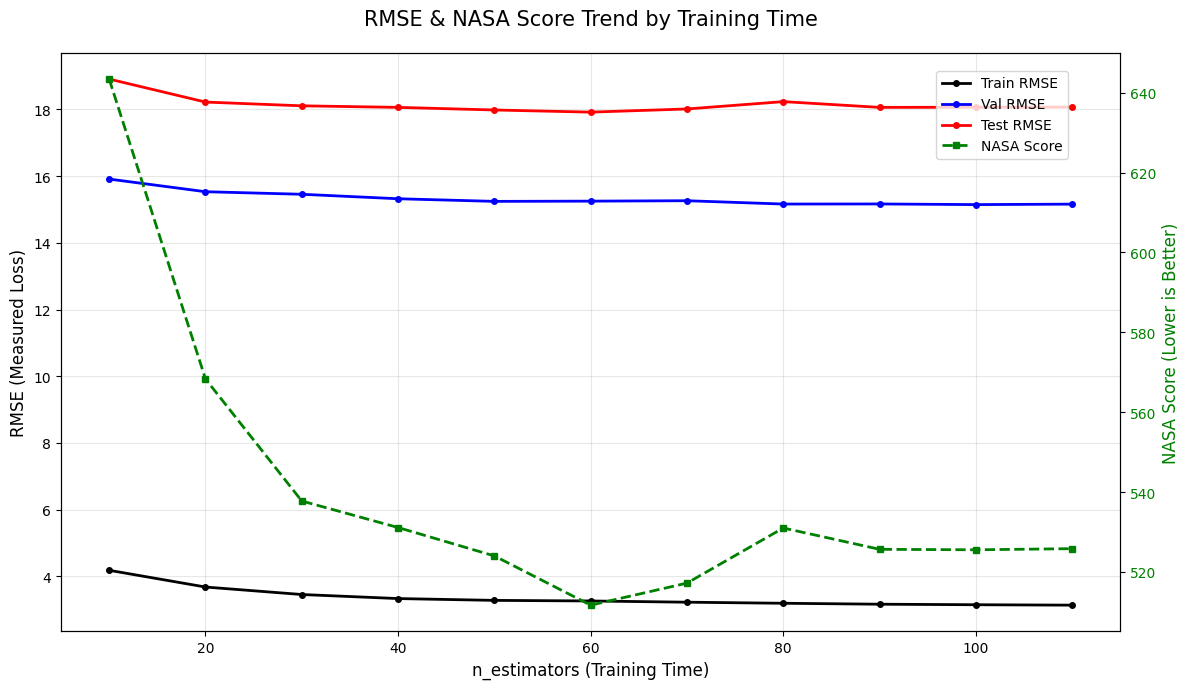


최적의 n_estimators: 60
최저 Test RMSE: 17.9138
그때의 NASA Score: 511.6612


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# 1. 기록을 위한 리스트 초기화 ㅋ
iterations = range(10, 111, 10) 
train_rmse_list, val_rmse_list, test_rmse_list = [], [], []
test_score_list = []

print("🚀 학습 횟수별 RMSE 및 NASA Score 기록 시작...")

for i in iterations:
    # --- RandomForest 모델로 교체 ㅋ ---
    model_tmp = RandomForestRegressor(
        n_estimators=i,
        random_state=CONFIG['RANDOM_STATE'],
        n_jobs=-1
    )
    
    model_tmp.fit(X_train, y_train)
    
    # RMSE 계산 ㅋ
    tr_rmse = np.sqrt(mean_squared_error(y_train, model_tmp.predict(X_train)))
    va_rmse = np.sqrt(mean_squared_error(y_val, model_tmp.predict(X_val)))
    
    # Test 평가 (에러 수정: plot 인자 제거 ㅋ)
    te_p = model_tmp.predict(X_test)
    te_rmse, te_score = evaluate_model(y_test, te_p, f"RF_{i}") 
    
    # 루프 돌 때마다 그래프 창이 뜨는 걸 방지하고 싶다면 아래 주석 해제 ㅋ
    plt.close() 
    
    train_rmse_list.append(tr_rmse)
    val_rmse_list.append(va_rmse)
    test_rmse_list.append(te_rmse)
    test_score_list.append(te_score)

# 2. 최종 통합 시각화 ㅋ
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 좌측 축: RMSE ---
ax1.plot(iterations, train_rmse_list, label='Train RMSE', color='black', lw=2, marker='o', markersize=4)
ax1.plot(iterations, val_rmse_list, label='Val RMSE', color='blue', lw=2, marker='o', markersize=4)
ax1.plot(iterations, test_rmse_list, label='Test RMSE', color='red', lw=2, marker='o', markersize=4)
ax1.set_xlabel('n_estimators (Training Time)', fontsize=12)
ax1.set_ylabel('RMSE (Measured Loss)', fontsize=12)
ax1.grid(True, alpha=0.3)

# --- 우측 축: NASA Score ---
ax2 = ax1.twinx() 
ax2.plot(iterations, test_score_list, label='NASA Score', color='green', lw=2, linestyle='--', marker='s', markersize=4)
ax2.set_ylabel('NASA Score (Lower is Better)', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

plt.title('RMSE & NASA Score Trend by Training Time', fontsize=15, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

# 최종 결과 요약 ㅋ
best_idx = np.argmin(test_rmse_list)
print(f"\n최적의 n_estimators: {iterations[best_idx]}")
print(f"최저 Test RMSE: {test_rmse_list[best_idx]:.4f}")
print(f"그때의 NASA Score: {test_score_list[best_idx]:.4f}")

# 최신 실행 모델 결과 시각화

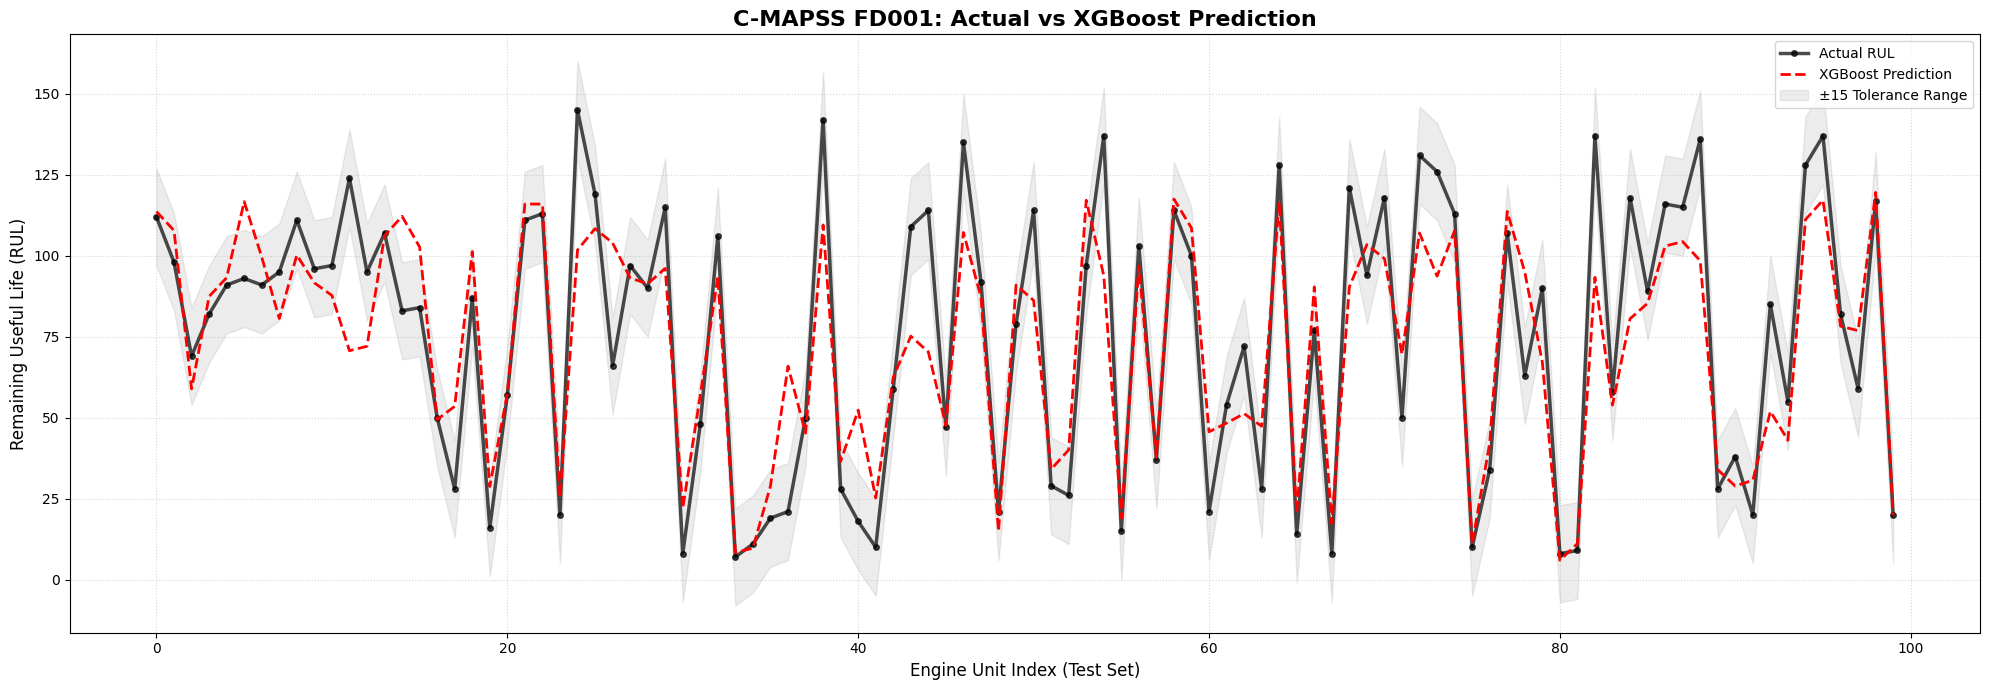

In [562]:
# 방금 실행한 모델의 예측값을 실제값과 비교합니다 ㅋ
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 7))

# 1. 실제 값 (정답)
plt.plot(y_test, label='Actual RUL', color='black', linewidth=2.5, marker='o', markersize=4, alpha=0.7)

# 2. 최신 모델 예측값
plt.plot(p_latest, label=f'{latest_name} Prediction', linestyle='--', color='red', linewidth=2)

# 제목 및 라벨
plt.title(f'C-MAPSS FD001: Actual vs {latest_name} Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Engine Unit Index (Test Set)', fontsize=12)
plt.ylabel('Remaining Useful Life (RUL)', fontsize=12)

# 오차 허용 범위 (±15) 시각화 ㅋ
plt.fill_between(range(len(y_test)), y_test-15, y_test+15, color='gray', alpha=0.15, label='±15 Tolerance Range')

plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [563]:
# 적합도 확인을 위한 RMSE 계산 ㅋ
train_rmse = np.sqrt(mean_squared_error(y_train, model_lgbm.predict(X_train)))
val_rmse   = np.sqrt(mean_squared_error(y_val, model_lgbm.predict(X_val)))
test_rmse  = lgbm_rmse # 아까 구한 17.97 ㅋ

print(f"--- [LightGBM 적합도 검증] ---")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Val   RMSE: {val_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")

--- [LightGBM 적합도 검증] ---
Train RMSE: 14.6174
Val   RMSE: 14.5093
Test  RMSE: 17.9715


+++++++++++++++++++++++++++++++++++++++++++++++++++++++

# 실제값 vs 예측값 비교 시각화

C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 50644 (\N{HANGUL SYLLABLE EN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 45937 (\N{HANGUL SYLLABLE DEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s

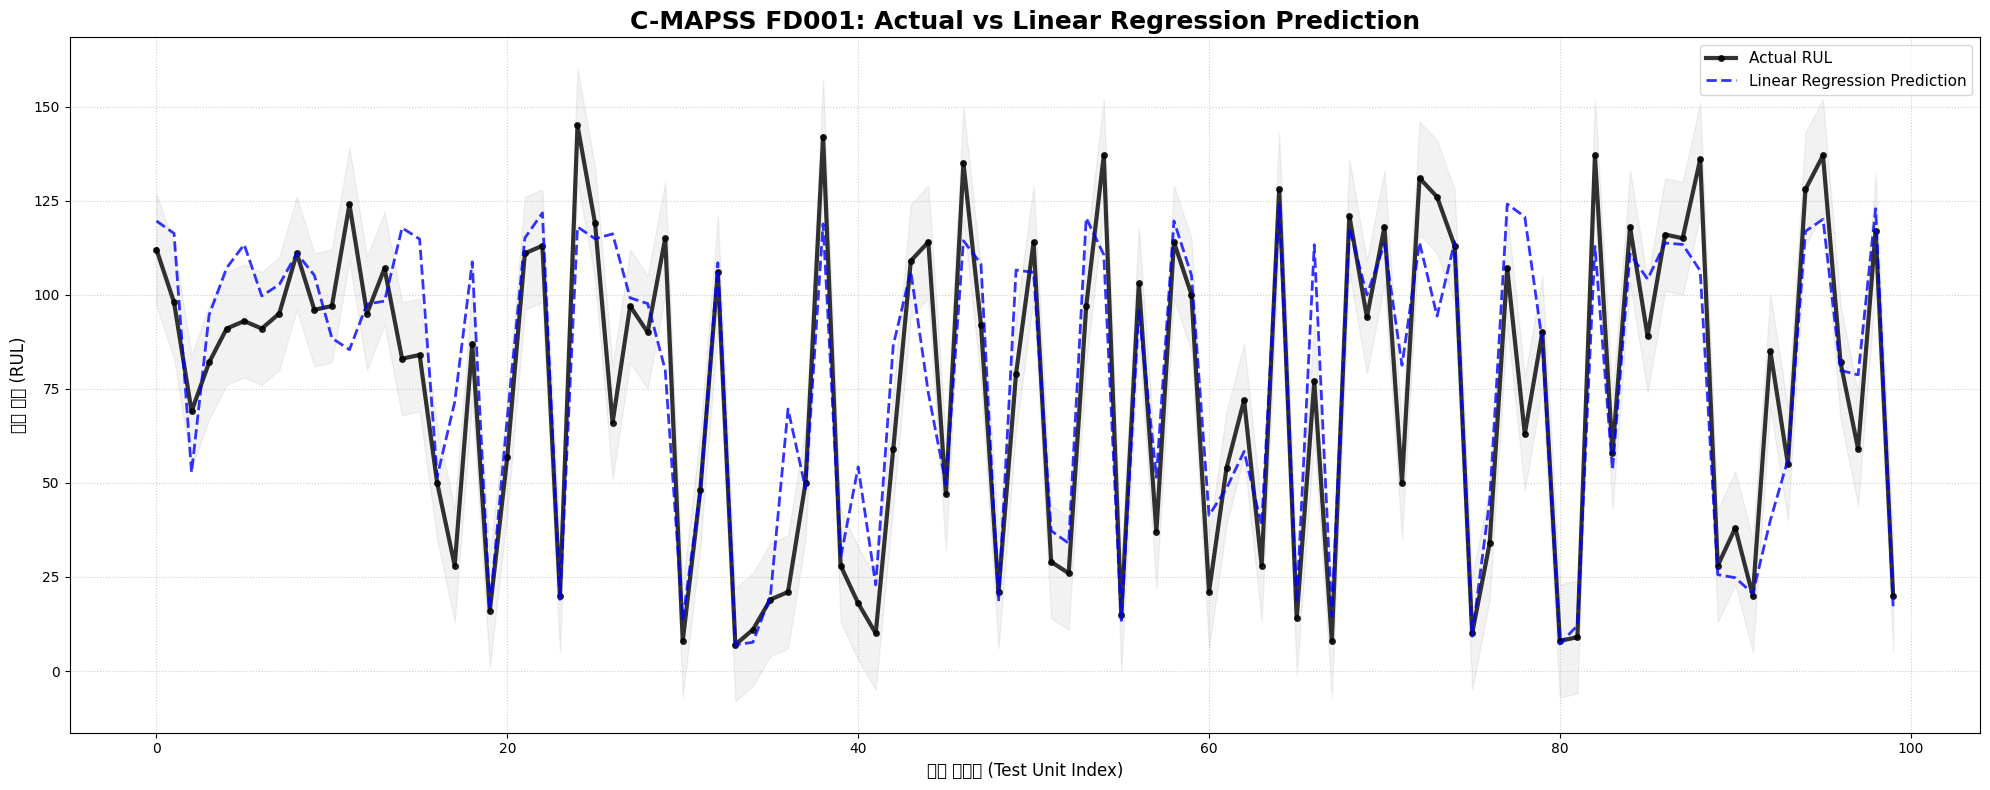

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

# 1. 실제 값 (정답)
plt.plot(y_test, 
         label='Actual RUL', 
         color='black', 
         linewidth=3, 
         marker='o', 
         markersize=4, 
         alpha=0.8)

# 2. Linear Regression 예측값
plt.plot(y_pred_lgb, 
         label='Linear Regression Prediction', 
         linestyle='--', 
         color='blue',
         linewidth=2,
         alpha=0.8)

# 제목 및 라벨
plt.title('C-MAPSS FD001: Actual vs Linear Regression Prediction', 
          fontsize=18, fontweight='bold')
plt.xlabel('엔진 인덱스 (Test Unit Index)', fontsize=12)
plt.ylabel('잔여 수명 (RUL)', fontsize=12)

# 범례
plt.legend(loc='upper right', fontsize=11)

# 격자
plt.grid(True, linestyle=':', alpha=0.6)

# 오차 허용 범위 (±15)
plt.fill_between(range(len(y_test)), 
                 y_test-15, 
                 y_test+15, 
                 color='gray', 
                 alpha=0.1,
                 label='±15 Tolerance')

plt.tight_layout()
plt.show()

In [15]:
import optuna
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# ---------------------------------------------------------
# [필수] NASA Scoring Function 정의 ㅋ
# ---------------------------------------------------------
def nasa_score(y_true, y_pred):
    """
    CMAPSS용 NASA Scoring Function
    d < 0 (조기 예측): exp(-d/10) - 1
    d > 0 (지연 예측): exp(d/13) - 1 (패널티 더 높음 ㅋ)
    """
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/10) - 1, np.exp(d/13) - 1)
    return np.sum(score)

# 결과 저장을 위한 딕셔너리
best_params_dict = {}

# ---------------------------------------------------------
# 모델별 Objective 함수 정의 (RMSE & NASA Score 실시간 출력) ㅋ
# ---------------------------------------------------------

# 1. Linear Regression
def objective_lr(trial):
    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 2. Ridge
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    model = Ridge(alpha=alpha, random_state=CONFIG['RANDOM_STATE'])
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 3. Lasso
def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    model = Lasso(alpha=alpha, random_state=CONFIG['RANDOM_STATE'])
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 4. ElasticNet
def objective_elastic(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=CONFIG['RANDOM_STATE'])
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 5. Random Forest
def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state': CONFIG['RANDOM_STATE'],
        'n_jobs': -1
    }
    model = RandomForestRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 6. XGBoost
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'tree_method': 'hist',
        'random_state': CONFIG['RANDOM_STATE']
    }
    model = XGBRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 7. LightGBM
def objective_lgbm(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'verbosity': -1,
        'random_state': CONFIG['RANDOM_STATE']
    }
    model = LGBMRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# ==========================================
# [최적화 실행 루프]
# ==========================================
objectives = {
    'Linear': objective_lr, 'Ridge': objective_ridge, 'Lasso': objective_lasso,
    'ElasticNet': objective_elastic, 'RF': objective_rf, 'XGB': objective_xgb, 'LGBM': objective_lgbm
}

for name, obj_func in objectives.items():
    print(f"\n🚀 {name} 최적화 시작...")
    # 로그 출력을 깔끔하게 하기 위해 optuna 기본 로그 수준 조절 ㅋ
    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    
    study = optuna.create_study(direction='minimize')
    study.optimize(obj_func, n_trials=20) 
    
    best_params_dict[name] = study.best_params
    print(f"✅ {name} 최적화 완료! Best RMSE: {study.best_value:.4f}")

print("\n" + "="*60)
print(" 모든 모델의 최적 파라미터 탐색 및 NASA Score 확인 완료! ㅋ")
print("="*60)


🚀 Linear 최적화 시작...
   [Trial 0] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 1] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 2] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 3] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 4] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 5] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 6] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 7] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 8] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 9] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 10] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 11] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 12] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 13] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 14] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 15] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 16] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 17] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 18] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 19] RMSE: 1

c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.131e+04, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


   [Trial 0] RMSE: 20.0220 | NASA Score: 32074.99


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.508e+03, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


   [Trial 1] RMSE: 20.3376 | NASA Score: 33930.72
   [Trial 2] RMSE: 23.6480 | NASA Score: 48903.51
   [Trial 3] RMSE: 24.8764 | NASA Score: 52099.08


...

   [Trial 16] RMSE: 20.2666 | NASA Score: 33553.76


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.948e+05, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


   [Trial 17] RMSE: 20.0055 | NASA Score: 32043.51


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.224e+06, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


   [Trial 18] RMSE: 19.9991 | NASA Score: 32027.52
   [Trial 19] RMSE: 20.2108 | NASA Score: 33579.74
✅ ElasticNet 최적화 완료! Best RMSE: 19.8401

🚀 RF 최적화 시작...
   [Trial 0] RMSE: 16.2871 | NASA Score: 20162.41
   [Trial 1] RMSE: 17.6185 | NASA Score: 24801.86
   [Trial 2] RMSE: 16.3547 | NASA Score: 19642.27
   [Trial 3] RMSE: 16.3303 | NASA Score: 19600.19
   [Trial 4] RMSE: 16.3272 | NASA Score: 20184.81
   [Trial 5] RMSE: 16.3641 | NASA Score: 19762.11
   [Trial 6] RMSE: 16.2750 | NASA Score: 20076.71
   [Trial 7] RMSE: 16.3252 | NASA Score: 20320.26
   [Trial 8] RMSE: 18.9165 | NASA Score: 32443.36
   [Trial 9] RMSE: 16.2736 | NASA Score: 19951.47
   [Trial 10] RMSE: 16.3493 | NASA Score: 20557.75
   [Trial 11] RMSE: 16.2644 | NASA Score: 19867.06
   [Trial 12] RMSE: 16.2957 | NASA Score: 20005.64
   [Trial 13] RMSE: 16.2793 | NASA Score: 19860.07
   [Trial 14] RMSE: 16.3132 | NASA Score: 20324.08
   [Trial 15] RMSE: 16.2766 | NASA Score: 19864.13
   [Trial 16] RMSE: 16.2954 | NASA S

In [17]:
# 최적화된 파라미터 확인 예시 ㅋ
import pprint
pprint.pprint(best_params_dict)

{'ElasticNet': {'alpha': 0.0011031157521679594, 'l1_ratio': 0.7698391053569069},
 'LGBM': {'lambda_l1': 6.581085980687492,
          'lambda_l2': 1.0262453967012054e-06,
          'learning_rate': 0.07331130347699083,
          'max_depth': 3,
          'n_estimators': 274,
          'num_leaves': 213},
 'Lasso': {'alpha': 0.002285157306815353},
 'Linear': {},
 'RF': {'max_depth': 11, 'min_samples_split': 13, 'n_estimators': 298},
 'Ridge': {'alpha': 0.0031531346643415285},
 'XGB': {'colsample_bytree': 0.7665966150914315,
         'learning_rate': 0.01631651345622754,
         'max_depth': 4,
         'n_estimators': 517,
         'subsample': 0.8328206428645647}}
